# Daily Snow Diagnostics From Discover Cat Files (OL vs DA)

This notebook reads **daily GEOSldas cat files** (same style/pattern used in `insitu_skill_ismn_network_ol_da.ipynb`) and computes seasonal snow diagnostics from the **daily values**:

- seasonal mean daily `SNOMASLAND`
- seasonal mean daily `FRLANDSNO` (snow cover fraction)
- seasonal **snow-covered days** count using `FRLANDSNO > 0.5`
- optional snow-covered day fraction (`snow_days / valid_days`)

It then summarizes **OL**, **DA**, and **DA-OL** by season (`DJF`, `MAM`, `JJA`, `SON`) and by user-defined periods.


## Approach (Why This Is Memory-Safe)

Reading every daily file for all tiles over many years is expensive. Storing all daily tile fields in memory is not.

So this notebook uses a **streaming seasonal accumulator**:

- loop over daily files
- read `SNOMASLAND` and `FRLANDSNO`
- update seasonal sums/counts for each tile
- write/load a compact **seasonal cache** (`exp x season-record x tile`)

This keeps the workflow simple and re-runnable.


In [1]:
# -------------------------
# Imports + configuration
# -------------------------
# Thread limits can help in notebook / restricted environments.
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

from pathlib import Path
import sys
import calendar
import warnings

# Silence noisy cartopy/shapely runtime warnings from geometry collection building.
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    message=r".*create_collection.*",
)
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"shapely\.creation",
)


# Silence known cartopy/shapely geometry warnings during map rendering.


import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import MaxNLocator

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAVE_CARTOPY = True
    CARTOPY_IMPORT_ERROR = None
except Exception as exc:
    HAVE_CARTOPY = False
    CARTOPY_IMPORT_ERROR = exc


# -------------------------
# Experiment definitions (edit for your Discover paths)
# -------------------------
# IMPORTANT: Each run_root should allow the helper to find:
#   run_root/output/<DOMAIN>/rc_out/<exp_name>.ldas_tilecoord.bin
#   run_root/output/<DOMAIN>/cat/ens_avg/Yyyyy/Mmm/<exp_name>.tavg24_1d_lnd_Nt.YYYYMMDD_1200z.nc4
EXPERIMENTS = {
    "OL": {
        "exp_name": "LS_OLv8_M36",
        "run_root": Path("/discover/nobackup/projects/land_da/M21C_land_sweeper/LS_OLv8_M36_v2/LS_OLv8_M36"),
    },
    "DA": {
        "exp_name": "LS_DAv8_M36",
        "run_root": Path("/discover/nobackup/projects/land_da/M21C_land_sweeper/LS_DAv8_M36_v3/LS_DAv8_M36"),
    },
}

DOMAIN = "SMAP_EASEv2_M36_GLOBAL"

# -------------------------
# Date range to scan daily files (inclusive)
# -------------------------
ANALYSIS_START = "2000-06-01"
ANALYSIS_END = "2024-05-31"

# Period windows used for period/season summaries (inclusive).
# These follow the breaks you requested previously.
PERIOD_WINDOWS = [
    ("2000-06 to 2007-05", "2000-06-01", "2007-05-31"),
    ("2007-06 to 2015-03", "2007-06-01", "2015-03-31"),
    ("2015-04 to 2024-05", "2015-04-01", "2024-05-31"),
]

SEASON_ORDER = ["DJF", "MAM", "JJA", "SON"]

# -------------------------
# Snow thresholds / QA settings
# -------------------------
SCF_THRESHOLD = 0.5  # snow-covered day if FRLANDSNO > 0.5
MIN_VALID_DAY_FRACTION_PER_SEASON = 0.90  # require this fraction of expected days for a season-record/tile

# -------------------------
# Region definitions (simple latitude masks; unweighted means)
# -------------------------
REGION_DEFS = {
    "Global": (-90.0, 90.0),
    "NH": (0.0, 90.0),
    "SH": (-90.0, 0.0),
    "NH (30-75N)": (30.0, 75.0),
    "High NH (45-75N)": (45.0, 75.0),
}
FOCUS_REGION = "NH (30-75N)"

# -------------------------
# Output / cache settings
# -------------------------
OUTPUT_DIR = Path("./outputs_daily_snow_seasonal_ol_da")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

_cache_tag = f"{DOMAIN}_{pd.Timestamp(ANALYSIS_START).strftime('%Y%m%d')}_{pd.Timestamp(ANALYSIS_END).strftime('%Y%m%d')}"
SEASONAL_CACHE_NC = OUTPUT_DIR / f"daily_snow_seasonal_cache_{_cache_tag}.nc"
PERIOD_TILE_SUMMARY_NC = OUTPUT_DIR / f"daily_snow_period_tile_summary_{_cache_tag}.nc"
PERIOD_REGION_SUMMARY_CSV = OUTPUT_DIR / f"daily_snow_period_region_summary_{_cache_tag}.csv"
SEASONAL_REGION_SERIES_CSV = OUTPUT_DIR / f"daily_snow_seasonal_region_series_{_cache_tag}.csv"

USE_SEASONAL_CACHE = True   # if cache exists, load it instead of re-reading daily files
WRITE_SEASONAL_CACHE = True # write/update cache after extraction
SAVE_FIGURES = True
FIG_DPI = 180

# Plot performance controls (map rendering)
MAP_TILE_STRIDE = 1  # only used by scatter fallback (pcolormesh ignores this)

# -------------------------
# Repo-local imports
# -------------------------
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "common/python/io/read_GEOSldas.py").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "common/python/io/read_GEOSldas.py").exists():
            REPO_ROOT = parent
            break

sys.path.insert(0, str(REPO_ROOT / "common/python/io"))
from read_GEOSldas import read_tilecoord  # type: ignore

print(f"REPO_ROOT={REPO_ROOT}")
print(f"DOMAIN={DOMAIN}")
print(f"ANALYSIS_START={ANALYSIS_START}")
print(f"ANALYSIS_END={ANALYSIS_END}")
print(f"SCF_THRESHOLD={SCF_THRESHOLD}")
print(f"MIN_VALID_DAY_FRACTION_PER_SEASON={MIN_VALID_DAY_FRACTION_PER_SEASON}")
print(f"SEASONAL_CACHE_NC={SEASONAL_CACHE_NC}")
print(f"HAVE_CARTOPY={HAVE_CARTOPY}")
for k, cfg in EXPERIMENTS.items():
    print(f"{k}: exp_name={cfg['exp_name']}, run_root={cfg['run_root']}")


REPO_ROOT=/Users/amfox/Desktop/geosldas-analysis
DOMAIN=SMAP_EASEv2_M36_GLOBAL
ANALYSIS_START=2000-06-01
ANALYSIS_END=2024-05-31
SCF_THRESHOLD=0.5
MIN_VALID_DAY_FRACTION_PER_SEASON=0.9
SEASONAL_CACHE_NC=outputs_daily_snow_seasonal_ol_da/daily_snow_seasonal_cache_SMAP_EASEv2_M36_GLOBAL_20000601_20240531.nc
HAVE_CARTOPY=True
OL: exp_name=LS_OLv8_M36, run_root=/discover/nobackup/projects/land_da/M21C_land_sweeper/LS_OLv8_M36_v2/LS_OLv8_M36
DA: exp_name=LS_DAv8_M36, run_root=/discover/nobackup/projects/land_da/M21C_land_sweeper/LS_DAv8_M36_v3/LS_DAv8_M36


## Helper Functions

These helpers mirror the daily-file discovery pattern used in the ISMN skill notebook, plus seasonal bookkeeping utilities.


In [2]:
# -------------------------
# File discovery + daily read helpers
# -------------------------
def locate_tilecoord_file(run_root: Path, exp_name: str, domain: str) -> Path:
    # Local-first override: allow running away from Discover by dropping tilecoord
    # into the same directory used for cache/output files (OUTPUT_DIR).
    cache_dir = Path(OUTPUT_DIR)

    candidates = [
        cache_dir / "tilecoord.bin",
        cache_dir / f"{exp_name}.ldas_tilecoord.bin",
        run_root / "output" / domain / "rc_out" / f"{exp_name}.ldas_tilecoord.bin",
        run_root / exp_name / "output" / domain / "rc_out" / f"{exp_name}.ldas_tilecoord.bin",
        run_root / f"{exp_name}.ldas_tilecoord.bin",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError("Could not find tilecoord file. Checked: " + ", ".join([str(p) for p in candidates]))


def locate_daily_cat_file(run_root: Path, exp_name: str, domain: str, day: pd.Timestamp):
    y = f"Y{day.year:04d}"
    m = f"M{day.month:02d}"
    stamp = day.strftime("%Y%m%d")
    fname = f"{exp_name}.tavg24_1d_lnd_Nt.{stamp}_1200z.nc4"

    candidates = [
        run_root / "output" / domain / "cat" / "ens_avg" / y / m / fname,
        run_root / exp_name / "output" / domain / "cat" / "ens_avg" / y / m / fname,
        run_root / "cat" / "ens_avg" / y / m / fname,
    ]
    for p in candidates:
        if p.exists():
            return p
    return None


def _read_var_1d_tile(ds, name):
    """Read one tile variable from a daily file, handling optional time dimension."""
    x = ds[name]
    if "time" in x.dims:
        x = x.isel(time=0)
    return np.asarray(x.values, dtype=np.float32)


def read_daily_snow_for_all_tiles(nc_path: Path):
    """Read SNOMASLAND and FRLANDSNO for all tiles from one daily file.

    Returns
    -------
    snomas : np.ndarray (tile,) float32
    frsno  : np.ndarray (tile,) float32
    """
    with xr.open_dataset(nc_path, decode_times=False) as ds:
        snomas = _read_var_1d_tile(ds, "SNOMASLAND")
        frsno = _read_var_1d_tile(ds, "FRLANDSNO")

    # Common fill-value handling.
    snomas[snomas > 1e14] = np.nan
    frsno[frsno > 1e14] = np.nan

    # Physical range checks (snow vars: zero is valid and must NOT be masked).
    snomas[snomas < 0.0] = np.nan
    frsno[(frsno < 0.0) | (frsno > 1.0 + 1e-4)] = np.nan

    return snomas, frsno


# -------------------------
# Seasonal bookkeeping helpers
# -------------------------
def season_name_and_year(day: pd.Timestamp):
    """Return (season, season_year) for a day.

    Convention:
    - DJF is labeled by January/February year (e.g., Dec 2014 -> DJF 2015)
    - MAM/JJA/SON use calendar year
    """
    m = int(day.month)
    y = int(day.year)

    if m in (12, 1, 2):
        return "DJF", (y + 1 if m == 12 else y)
    if m in (3, 4, 5):
        return "MAM", y
    if m in (6, 7, 8):
        return "JJA", y
    return "SON", y


def season_bounds(season: str, season_year: int):
    """Return (start, end) timestamps for a season record."""
    season = str(season)
    season_year = int(season_year)

    if season == "DJF":
        start = pd.Timestamp(year=season_year - 1, month=12, day=1)
        end = pd.Timestamp(year=season_year, month=2, day=calendar.monthrange(season_year, 2)[1])
    elif season == "MAM":
        start = pd.Timestamp(year=season_year, month=3, day=1)
        end = pd.Timestamp(year=season_year, month=5, day=31)
    elif season == "JJA":
        start = pd.Timestamp(year=season_year, month=6, day=1)
        end = pd.Timestamp(year=season_year, month=8, day=31)
    elif season == "SON":
        start = pd.Timestamp(year=season_year, month=9, day=1)
        end = pd.Timestamp(year=season_year, month=11, day=30)
    else:
        raise ValueError(f"Unsupported season={season}")

    return start, end


def build_season_records_for_days(days: pd.DatetimeIndex):
    """Build season-record metadata and a day->record index mapping.

    Returns
    -------
    season_records_df : DataFrame
        One row per season record (e.g., DJF 2015)
    day_to_record_idx : dict[pd.Timestamp -> int]
        Maps normalized day to row index in season_records_df
    """
    if len(days) == 0:
        raise ValueError("days is empty")

    # Count days in analysis span for each season record.
    record_counts = {}
    for day in pd.DatetimeIndex(days):
        d = pd.Timestamp(day).normalize()
        season, season_year = season_name_and_year(d)
        key = (season, int(season_year))
        record_counts[key] = record_counts.get(key, 0) + 1

    rows = []
    for (season, season_year), n_in_span in record_counts.items():
        s0, s1 = season_bounds(season, season_year)
        n_expected = int((s1 - s0).days + 1)
        rows.append(
            {
                "season": season,
                "season_year": int(season_year),
                "season_start": s0,
                "season_end": s1,
                "n_days_expected": n_expected,
                "n_days_in_analysis_span": int(n_in_span),
                "complete_within_analysis_span": bool(int(n_in_span) == n_expected),
            }
        )

    season_records_df = pd.DataFrame(rows)

    # Sort chronologically by true season start date.
    season_records_df = season_records_df.sort_values(["season_start", "season_year", "season"]).reset_index(drop=True)
    season_records_df["record"] = np.arange(len(season_records_df), dtype=np.int32)

    # Build day -> record index lookup.
    key_to_record = {
        (str(r.season), int(r.season_year)): int(r.record)
        for r in season_records_df.itertuples(index=False)
    }
    day_to_record_idx = {}
    for day in pd.DatetimeIndex(days):
        d = pd.Timestamp(day).normalize()
        season, season_year = season_name_and_year(d)
        day_to_record_idx[d] = int(key_to_record[(season, int(season_year))])

    return season_records_df, day_to_record_idx


def build_window_bounds(windows):
    out = []
    for name, start, end in windows:
        out.append((name, pd.Timestamp(start), pd.Timestamp(end)))
    return out


# -------------------------
# Plot helpers (cartopy + pcolormesh preferred; scatter fallback kept)
# -------------------------
def robust_symmetric_limits(values, pct=99.0, pad_frac=0.03):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return (-1.0, 1.0)
    vmax = np.nanpercentile(np.abs(arr), pct)
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = np.nanmax(np.abs(arr)) if arr.size else 1.0
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    vmax = float(vmax) * (1.0 + pad_frac)
    return (-vmax, vmax)


def savefig_if_enabled(fig, filename, output_dir=OUTPUT_DIR, save=True, dpi=180):
    if not save:
        return None
    p = Path(output_dir) / filename
    fig.savefig(p, dpi=dpi, bbox_inches="tight")
    print(f"Wrote figure: {p}")
    return p


def make_region_masks(lat_da, region_defs):
    masks = {}
    for name, (lat0, lat1) in region_defs.items():
        masks[name] = (lat_da >= lat0) & (lat_da <= lat1)
    return masks


def plot_period_season_scatter_maps(period_tile_ds, var_name, title, units="", cmap="RdBu_r", stride=1, pct=99.0):
    """Plot rows=periods, cols=seasons using lon/lat scatter (no cartopy)."""
    periods = [str(x) for x in period_tile_ds["period"].values]
    seasons = [str(x) for x in period_tile_ds["season"].values]
    lat = np.asarray(period_tile_ds["lat"].values, dtype=float)
    lon = np.asarray(period_tile_ds["lon"].values, dtype=float)
    vals = np.asarray(period_tile_ds[var_name].values, dtype=float)  # [period, season, tile]

    sl = slice(None, None, max(1, int(stride)))
    latp = lat[sl]
    lonp = lon[sl]
    valsp = vals[:, :, sl]

    vmin, vmax = robust_symmetric_limits(valsp, pct=pct)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

    fig, axes = plt.subplots(len(periods), len(seasons), figsize=(3.8 * len(seasons), 3.0 * len(periods)), sharex=True, sharey=True, constrained_layout=True)
    axes = np.atleast_2d(axes)

    sc = None
    for i, p in enumerate(periods):
        for j, s in enumerate(seasons):
            ax = axes[i, j]
            x = valsp[i, j, :]
            m = np.isfinite(x) & np.isfinite(latp) & np.isfinite(lonp)
            if np.any(m):
                sc = ax.scatter(lonp[m], latp[m], c=x[m], s=4, cmap=cmap, norm=norm, linewidths=0)
            ax.axhline(0, color='none')
            ax.grid(alpha=0.15)
            ax.set_xlim(-180, 180)
            ax.set_ylim(-90, 90)
            if i == 0:
                ax.set_title(s)
            if j == 0:
                ax.set_ylabel(p)

    for ax in axes[-1, :]:
        ax.set_xlabel("Lon")
    for ax in axes[:, 0]:
        ax.set_ylabel(ax.get_ylabel() + "\nLat")

    if sc is not None:
        cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.9)
        cbar.set_label(units if units else var_name)
    fig.suptitle(title, fontsize=14)
    return fig




def _centers_to_edges(centers_1d):
    """Convert 1D monotonic center coordinates to edge coordinates for pcolormesh."""
    c = np.asarray(centers_1d, dtype=float)
    if c.ndim != 1 or c.size == 0:
        raise ValueError("centers_1d must be a non-empty 1D array")
    if c.size == 1:
        return np.array([c[0] - 0.5, c[0] + 0.5], dtype=float)

    dc = np.diff(c)
    if not np.all(dc > 0):
        raise ValueError("centers_1d must be strictly increasing")

    mids = 0.5 * (c[:-1] + c[1:])
    first = c[0] - 0.5 * dc[0]
    last = c[-1] + 0.5 * dc[-1]
    return np.concatenate(([first], mids, [last]))


def build_tile_pcolormesh_grid(lat_1d, lon_1d, round_decimals=6):
    """Reconstruct a sparse rectilinear grid from land-tile lat/lon centers.

    The tilecoord arrays are land-only, but the underlying EASE tile geometry is typically
    rectilinear in (lat, lon). This helper builds a full 2D grid and leaves non-land cells as NaN.
    """
    lat = np.asarray(lat_1d, dtype=float).ravel()
    lon = np.asarray(lon_1d, dtype=float).ravel()
    if lat.size != lon.size:
        raise ValueError("lat and lon must have the same length")

    # Round to avoid floating-point noise creating artificial unique coordinates.
    lat_r = np.round(lat, int(round_decimals))
    lon_r = np.round(lon, int(round_decimals))

    lat_unique = np.unique(lat_r)
    lon_unique = np.unique(lon_r)
    lat_unique.sort()
    lon_unique.sort()

    i_lat = np.searchsorted(lat_unique, lat_r)
    i_lon = np.searchsorted(lon_unique, lon_r)

    # Validate exact membership after rounding.
    if not np.all(lat_unique[i_lat] == lat_r):
        raise RuntimeError("Failed to map tile latitudes onto unique latitude centers")
    if not np.all(lon_unique[i_lon] == lon_r):
        raise RuntimeError("Failed to map tile longitudes onto unique longitude centers")

    # A land tile grid should not have duplicate (lat, lon) pairs.
    pair_code = i_lat.astype(np.int64) * np.int64(lon_unique.size) + i_lon.astype(np.int64)
    if np.unique(pair_code).size != pair_code.size:
        raise RuntimeError("Duplicate rounded (lat, lon) tile centers detected; cannot build pcolormesh grid safely")

    lat_edges = _centers_to_edges(lat_unique)
    lon_edges = _centers_to_edges(lon_unique)
    lon_edges_2d, lat_edges_2d = np.meshgrid(lon_edges, lat_edges)

    return {
        "lat_unique": lat_unique,
        "lon_unique": lon_unique,
        "lat_edges": lat_edges,
        "lon_edges": lon_edges,
        "lat_edges_2d": lat_edges_2d,
        "lon_edges_2d": lon_edges_2d,
        "i_lat": i_lat.astype(np.int32),
        "i_lon": i_lon.astype(np.int32),
        "nlat": int(lat_unique.size),
        "nlon": int(lon_unique.size),
        "n_tile": int(lat.size),
        "round_decimals": int(round_decimals),
    }


def tile_values_to_grid2d(tile_values, grid_spec, dtype=np.float32):
    """Map a tile vector onto a 2D rectilinear grid (NaN for non-land cells)."""
    v = np.asarray(tile_values, dtype=float).ravel()
    if v.size != int(grid_spec["n_tile"]):
        raise ValueError(f"tile_values length {v.size} does not match grid n_tile={grid_spec['n_tile']}")

    out = np.full((int(grid_spec["nlat"]), int(grid_spec["nlon"])), np.nan, dtype=dtype)
    out[grid_spec["i_lat"], grid_spec["i_lon"]] = v.astype(dtype, copy=False)
    return out


def plot_period_season_cartopy_pcolormesh_maps(period_tile_ds, var_name, title, units="", cmap="RdBu_r", pct=99.0, tile_grid_spec=None):
    """Plot rows=periods, cols=seasons using cartopy + pcolormesh on a reconstructed tile grid."""
    if not HAVE_CARTOPY:
        raise ImportError(f"cartopy is required for this map function: {CARTOPY_IMPORT_ERROR}")

    periods = [str(x) for x in period_tile_ds["period"].values]
    seasons = [str(x) for x in period_tile_ds["season"].values]
    lat = np.asarray(period_tile_ds["lat"].values, dtype=float)
    lon = np.asarray(period_tile_ds["lon"].values, dtype=float)
    vals = np.asarray(period_tile_ds[var_name].values, dtype=float)  # [period, season, tile]

    if tile_grid_spec is None:
        tile_grid_spec = build_tile_pcolormesh_grid(lat, lon)

    vmin, vmax = robust_symmetric_limits(vals, pct=pct)
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)

    proj = ccrs.Robinson()
    pc = ccrs.PlateCarree()

    fig, axes = plt.subplots(
        len(periods),
        len(seasons),
        figsize=(4.0 * len(seasons), 3.0 * len(periods)),
        subplot_kw={"projection": proj},
        constrained_layout=True,
    )
    axes = np.atleast_2d(axes)

    pcm = None
    for i, p in enumerate(periods):
        for j, s in enumerate(seasons):
            ax = axes[i, j]
            z2d = tile_values_to_grid2d(vals[i, j, :], tile_grid_spec, dtype=np.float32)
            pcm = ax.pcolormesh(
                tile_grid_spec["lon_edges_2d"],
                tile_grid_spec["lat_edges_2d"],
                z2d,
                transform=pc,
                cmap=cmap,
                norm=norm,
                shading="auto",
                rasterized=True,
            )
            ax.coastlines(linewidth=0.5)
            try:
                ax.add_feature(cfeature.BORDERS, linewidth=0.25, edgecolor="0.3")
            except Exception:
                pass
            ax.set_global()
            if i == 0:
                ax.set_title(s)
            if j == 0:
                ax.text(
                    -0.05,
                    0.5,
                    p,
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=10,
                )

    if pcm is not None:
        cbar = fig.colorbar(pcm, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
        cbar.set_label(units if units else var_name)
    fig.suptitle(title, fontsize=14)
    return fig


## Build Day List and Season Records

This cell creates the daily loop index and the season-record table (e.g., `DJF 2015`, `MAM 2015`, ...). `DJF` is labeled by Jan/Feb year.


In [3]:
# -------------------------
# Build analysis day list and season-record metadata
# -------------------------
analysis_days = pd.date_range(pd.Timestamp(ANALYSIS_START), pd.Timestamp(ANALYSIS_END), freq="D")
season_records_df, day_to_record_idx = build_season_records_for_days(analysis_days)
window_bounds = build_window_bounds(PERIOD_WINDOWS)

print(f"Analysis days: {analysis_days[0].date()} to {analysis_days[-1].date()} ({len(analysis_days)} days)")
print(f"Season records: {len(season_records_df)}")
print("Period windows:")
for name, t0, t1 in window_bounds:
    print(f"  {name}: {t0.date()} to {t1.date()}")

display(season_records_df.head(12))
display(season_records_df.tail(12))


Analysis days: 2000-06-01 to 2024-05-31 (8766 days)
Season records: 96
Period windows:
  2000-06 to 2007-05: 2000-06-01 to 2007-05-31
  2007-06 to 2015-03: 2007-06-01 to 2015-03-31
  2015-04 to 2024-05: 2015-04-01 to 2024-05-31


,season,season_year,season_start,season_end,n_days_expected,n_days_in_analysis_span,complete_within_analysis_span,record
0,JJA,2000,2000-06-01,2000-08-31,92,92,True,0
1,SON,2000,2000-09-01,2000-11-30,91,91,True,1
2,DJF,2001,2000-12-01,2001-02-28,90,90,True,2
3,MAM,2001,2001-03-01,2001-05-31,92,92,True,3
4,JJA,2001,2001-06-01,2001-08-31,92,92,True,4
5,SON,2001,2001-09-01,2001-11-30,91,91,True,5
6,DJF,2002,2001-12-01,2002-02-28,90,90,True,6
7,MAM,2002,2002-03-01,2002-05-31,92,92,True,7
8,JJA,2002,2002-06-01,2002-08-31,92,92,True,8
9,SON,2002,2002-09-01,2002-11-30,91,91,True,9


,season,season_year,season_start,season_end,n_days_expected,n_days_in_analysis_span,complete_within_analysis_span,record
84,JJA,2021,2021-06-01,2021-08-31,92,92,True,84
85,SON,2021,2021-09-01,2021-11-30,91,91,True,85
86,DJF,2022,2021-12-01,2022-02-28,90,90,True,86
87,MAM,2022,2022-03-01,2022-05-31,92,92,True,87
88,JJA,2022,2022-06-01,2022-08-31,92,92,True,88
89,SON,2022,2022-09-01,2022-11-30,91,91,True,89
90,DJF,2023,2022-12-01,2023-02-28,90,90,True,90
91,MAM,2023,2023-03-01,2023-05-31,92,92,True,91
92,JJA,2023,2023-06-01,2023-08-31,92,92,True,92
93,SON,2023,2023-09-01,2023-11-30,91,91,True,93


## Extract Daily Snow Variables and Build Seasonal Cache (or Load Existing Cache)

This is the heavy step. It loops over daily files, reads `SNOMASLAND` and `FRLANDSNO`, and updates seasonal accumulators for each tile.

Cache contents (compact):
- seasonal mean daily `SNOMASLAND`
- seasonal mean daily `FRLANDSNO`
- seasonal snow-covered day counts (`FRLANDSNO > 0.5`)
- seasonal valid-day counts


In [4]:
# -------------------------
# Extract daily files into a seasonal cache (or load existing cache)
# -------------------------
loaded_from_cache = False
seasonal_ds = None

if USE_SEASONAL_CACHE and SEASONAL_CACHE_NC.exists():
    print(f"Loading seasonal cache: {SEASONAL_CACHE_NC}")
    with xr.open_dataset(SEASONAL_CACHE_NC) as ds_in:
        seasonal_ds = ds_in.load()
    loaded_from_cache = True

if not loaded_from_cache:
    print("Running daily extraction and seasonal accumulation from cat files...")

    exp_keys = list(EXPERIMENTS.keys())
    n_exp = len(exp_keys)
    n_rec = len(season_records_df)

    # Will be filled after reading tilecoord from the first experiment.
    tile_lat = None
    tile_lon = None
    n_tile = None

    # Storage by experiment key; arrays are [record, tile].
    accum = {}

    for exp_key in exp_keys:
        cfg = EXPERIMENTS[exp_key]
        exp_name = str(cfg["exp_name"])
        run_root = Path(cfg["run_root"])

        print("=" * 88)
        print(f"Experiment {exp_key}: {exp_name}")

        tilecoord_path = locate_tilecoord_file(run_root, exp_name, DOMAIN)
        tc = read_tilecoord(str(tilecoord_path))
        this_lat = np.asarray(tc["com_lat"], dtype=np.float32)
        this_lon = np.asarray(tc["com_lon"], dtype=np.float32)

        if tile_lat is None:
            tile_lat = this_lat.copy()
            tile_lon = this_lon.copy()
            n_tile = int(tile_lat.size)
            print(f"Tile count: {n_tile}")
        else:
            if this_lat.size != n_tile or this_lon.size != n_tile:
                raise RuntimeError(f"Tilecoord size mismatch for {exp_key}")
            if not np.allclose(this_lat, tile_lat, equal_nan=True) or not np.allclose(this_lon, tile_lon, equal_nan=True):
                raise RuntimeError(f"Tilecoord lat/lon mismatch between experiments (failed on {exp_key})")

        # Preallocate accumulators for this experiment.
        # float32 is sufficient for seasonal sums here and keeps memory moderate.
        snomas_sum = np.zeros((n_rec, n_tile), dtype=np.float32)
        scf_sum = np.zeros((n_rec, n_tile), dtype=np.float32)
        valid_snomas_days = np.zeros((n_rec, n_tile), dtype=np.int16)
        valid_scf_days = np.zeros((n_rec, n_tile), dtype=np.int16)
        snowcovered_days = np.zeros((n_rec, n_tile), dtype=np.int16)
        files_found_per_record = np.zeros((n_rec,), dtype=np.int16)

        n_found = 0
        for i, day in enumerate(analysis_days):
            f = locate_daily_cat_file(run_root, exp_name, DOMAIN, pd.Timestamp(day))
            if f is None:
                continue

            snomas, frsno = read_daily_snow_for_all_tiles(f)
            if n_tile is not None and (snomas.size != n_tile or frsno.size != n_tile):
                raise RuntimeError(f"Tile count mismatch in {f}")

            ri = int(day_to_record_idx[pd.Timestamp(day).normalize()])

            m_snomas = np.isfinite(snomas)
            m_scf = np.isfinite(frsno)
            m_snow = m_scf & (frsno > float(SCF_THRESHOLD))

            # Update seasonal sums / counts for this day and season-record.
            # Zero snow values are valid and remain in the mean/count logic.
            if np.any(m_snomas):
                snomas_sum[ri, m_snomas] += snomas[m_snomas]
                valid_snomas_days[ri, m_snomas] += 1
            if np.any(m_scf):
                scf_sum[ri, m_scf] += frsno[m_scf]
                valid_scf_days[ri, m_scf] += 1
            if np.any(m_snow):
                snowcovered_days[ri, m_snow] += 1

            files_found_per_record[ri] += 1
            n_found += 1

            if (i + 1) % 365 == 0 or (i + 1) == len(analysis_days):
                print(f"  {exp_key}: checked {i + 1}/{len(analysis_days)} days, files found={n_found}")

        # Convert sums to means using valid-day counts.
        snomas_mean = np.full((n_rec, n_tile), np.nan, dtype=np.float32)
        scf_mean = np.full((n_rec, n_tile), np.nan, dtype=np.float32)
        snowday_frac = np.full((n_rec, n_tile), np.nan, dtype=np.float32)

        np.divide(
            snomas_sum,
            valid_snomas_days,
            out=snomas_mean,
            where=valid_snomas_days > 0,
        )
        np.divide(
            scf_sum,
            valid_scf_days,
            out=scf_mean,
            where=valid_scf_days > 0,
        )
        np.divide(
            snowcovered_days,
            valid_scf_days,
            out=snowday_frac,
            where=valid_scf_days > 0,
        )

        accum[exp_key] = {
            "snomas_mean_daily": snomas_mean,
            "frlandsno_mean_daily": scf_mean,
            "snowcovered_days": snowcovered_days.astype(np.int16),
            "snowcovered_day_fraction": snowday_frac,
            "valid_snomas_days": valid_snomas_days,
            "valid_scf_days": valid_scf_days,
            "files_found_per_record": files_found_per_record,
            "n_daily_files_found_total": int(n_found),
        }

        print(f"{exp_key}: daily files found = {n_found} / {len(analysis_days)}")

    # Assemble one compact xarray dataset with dims (exp, record, tile).
    exp_keys = list(EXPERIMENTS.keys())
    n_exp = len(exp_keys)
    n_rec = len(season_records_df)
    n_tile = int(tile_lat.size)

    def stack_var(name, dtype=np.float32):
        arr = np.empty((n_exp, n_rec, n_tile), dtype=dtype)
        for ie, exp_key in enumerate(exp_keys):
            arr[ie, :, :] = accum[exp_key][name]
        return arr

    files_found_per_record_arr = np.empty((n_exp, n_rec), dtype=np.int16)
    files_found_total_arr = np.empty((n_exp,), dtype=np.int32)
    for ie, exp_key in enumerate(exp_keys):
        files_found_per_record_arr[ie, :] = accum[exp_key]["files_found_per_record"]
        files_found_total_arr[ie] = int(accum[exp_key]["n_daily_files_found_total"])

    seasonal_ds = xr.Dataset(
        data_vars={
            "snomas_mean_daily": (("exp", "record", "tile"), stack_var("snomas_mean_daily", dtype=np.float32)),
            "frlandsno_mean_daily": (("exp", "record", "tile"), stack_var("frlandsno_mean_daily", dtype=np.float32)),
            "snowcovered_days": (("exp", "record", "tile"), stack_var("snowcovered_days", dtype=np.int16)),
            "snowcovered_day_fraction": (("exp", "record", "tile"), stack_var("snowcovered_day_fraction", dtype=np.float32)),
            "valid_snomas_days": (("exp", "record", "tile"), stack_var("valid_snomas_days", dtype=np.int16)),
            "valid_scf_days": (("exp", "record", "tile"), stack_var("valid_scf_days", dtype=np.int16)),
            "files_found_per_record": (("exp", "record"), files_found_per_record_arr),
            "files_found_total": (("exp",), files_found_total_arr),
            "lat": (("tile",), np.asarray(tile_lat, dtype=np.float32)),
            "lon": (("tile",), np.asarray(tile_lon, dtype=np.float32)),
            "season_year": (("record",), season_records_df["season_year"].to_numpy(dtype=np.int32)),
            "season_start": (("record",), season_records_df["season_start"].to_numpy(dtype="datetime64[ns]")),
            "season_end": (("record",), season_records_df["season_end"].to_numpy(dtype="datetime64[ns]")),
            "n_days_expected": (("record",), season_records_df["n_days_expected"].to_numpy(dtype=np.int16)),
            "n_days_in_analysis_span": (("record",), season_records_df["n_days_in_analysis_span"].to_numpy(dtype=np.int16)),
            "complete_within_analysis_span": (("record",), season_records_df["complete_within_analysis_span"].to_numpy(dtype=np.int8)),
        },
        coords={
            "exp": np.array(exp_keys, dtype="U8"),
            "record": np.arange(n_rec, dtype=np.int32),
            "tile": np.arange(n_tile, dtype=np.int32),
            "season": (("record",), season_records_df["season"].to_numpy(dtype="U3")),
        },
        attrs={
            "domain": str(DOMAIN),
            "analysis_start": str(pd.Timestamp(ANALYSIS_START).date()),
            "analysis_end": str(pd.Timestamp(ANALYSIS_END).date()),
            "scf_threshold": float(SCF_THRESHOLD),
            "min_valid_day_fraction_per_season": float(MIN_VALID_DAY_FRACTION_PER_SEASON),
            "note": "Seasonal diagnostics computed from daily cat files via streaming accumulators",
            "created_utc": pd.Timestamp.utcnow().isoformat(),
        },
    )

    # Attach experiment metadata as attrs (simple and visible in ncdump -h).
    for exp_key in exp_keys:
        seasonal_ds.attrs[f"exp_name_{exp_key}"] = str(EXPERIMENTS[exp_key]["exp_name"])
        seasonal_ds.attrs[f"run_root_{exp_key}"] = str(EXPERIMENTS[exp_key]["run_root"])

    if WRITE_SEASONAL_CACHE:
        print(f"Writing seasonal cache: {SEASONAL_CACHE_NC}")
        seasonal_ds.to_netcdf(SEASONAL_CACHE_NC)
        print(f"Wrote seasonal cache: {SEASONAL_CACHE_NC}")

print(seasonal_ds)


Loading seasonal cache: outputs_daily_snow_seasonal_ol_da/daily_snow_seasonal_cache_SMAP_EASEv2_M36_GLOBAL_20000601_20240531.nc
<xarray.Dataset> Size: 390MB
Dimensions:                        (exp: 2, record: 96, tile: 112573)
Coordinates:
  * exp                            (exp) <U2 16B 'OL' 'DA'
  * record                         (record) int32 384B 0 1 2 3 4 ... 92 93 94 95
  * tile                           (tile) int32 450kB 0 1 2 ... 112571 112572
    season                         (record) <U3 1kB 'JJA' 'SON' ... 'DJF' 'MAM'
Data variables: (12/16)
    snomas_mean_daily              (exp, record, tile) float32 86MB 18.43 ......
    frlandsno_mean_daily           (exp, record, tile) float32 86MB 0.4756 .....
    snowcovered_days               (exp, record, tile) int16 43MB 48 34 ... 0 88
    snowcovered_day_fraction       (exp, record, tile) float32 86MB 0.5217 .....
    valid_snomas_days              (exp, record, tile) int16 43MB 92 92 ... 92
    valid_scf_days                 

## Quick Checks on Seasonal Cache

This verifies dimensional consistency, basic coverage, and file availability by experiment.


In [5]:
# -------------------------
# Quick checks on seasonal cache contents
# -------------------------
if seasonal_ds is None:
    raise RuntimeError("seasonal_ds is not available")

exp_values = [str(x) for x in seasonal_ds["exp"].values]
record_count = int(seasonal_ds.sizes["record"])
tile_count = int(seasonal_ds.sizes["tile"])

print(f"Experiments: {exp_values}")
print(f"Records: {record_count}")
print(f"Tiles: {tile_count}")
print(f"Seasons in cache: {sorted(set([str(x) for x in seasonal_ds['season'].values]))}")

for exp_key in exp_values:
    total = int(seasonal_ds["files_found_total"].sel(exp=exp_key).values)
    print(f"{exp_key}: files_found_total={total} / {len(analysis_days)}")

record_meta_df = pd.DataFrame(
    {
        "record": seasonal_ds["record"].values.astype(int),
        "season": seasonal_ds["season"].values.astype(str),
        "season_year": seasonal_ds["season_year"].values.astype(int),
        "season_start": pd.to_datetime(seasonal_ds["season_start"].values),
        "season_end": pd.to_datetime(seasonal_ds["season_end"].values),
        "n_days_expected": seasonal_ds["n_days_expected"].values.astype(int),
        "n_days_in_analysis_span": seasonal_ds["n_days_in_analysis_span"].values.astype(int),
        "complete_within_analysis_span": seasonal_ds["complete_within_analysis_span"].values.astype(int).astype(bool),
    }
)

display(record_meta_df.head(12))

display(record_meta_df.tail(12))


Experiments: ['OL', 'DA']
Records: 96
Tiles: 112573
Seasons in cache: ['DJF', 'JJA', 'MAM', 'SON']
OL: files_found_total=8766 / 8766
DA: files_found_total=8766 / 8766


,record,season,season_year,season_start,season_end,n_days_expected,n_days_in_analysis_span,complete_within_analysis_span
0,0,JJA,2000,2000-06-01,2000-08-31,92,92,True
1,1,SON,2000,2000-09-01,2000-11-30,91,91,True
2,2,DJF,2001,2000-12-01,2001-02-28,90,90,True
3,3,MAM,2001,2001-03-01,2001-05-31,92,92,True
4,4,JJA,2001,2001-06-01,2001-08-31,92,92,True
5,5,SON,2001,2001-09-01,2001-11-30,91,91,True
6,6,DJF,2002,2001-12-01,2002-02-28,90,90,True
7,7,MAM,2002,2002-03-01,2002-05-31,92,92,True
8,8,JJA,2002,2002-06-01,2002-08-31,92,92,True
9,9,SON,2002,2002-09-01,2002-11-30,91,91,True


,record,season,season_year,season_start,season_end,n_days_expected,n_days_in_analysis_span,complete_within_analysis_span
84,84,JJA,2021,2021-06-01,2021-08-31,92,92,True
85,85,SON,2021,2021-09-01,2021-11-30,91,91,True
86,86,DJF,2022,2021-12-01,2022-02-28,90,90,True
87,87,MAM,2022,2022-03-01,2022-05-31,92,92,True
88,88,JJA,2022,2022-06-01,2022-08-31,92,92,True
89,89,SON,2022,2022-09-01,2022-11-30,91,91,True
90,90,DJF,2023,2022-12-01,2023-02-28,90,90,True
91,91,MAM,2023,2023-03-01,2023-05-31,92,92,True
92,92,JJA,2023,2023-06-01,2023-08-31,92,92,True
93,93,SON,2023,2023-09-01,2023-11-30,91,91,True


## Build Period/Season Tile Summaries and Region Summaries (`OL`, `DA`, `DA-OL`)

This cell computes period-season means by tile for:

- `SNOMASLAND` seasonal mean daily value
- `FRLANDSNO` seasonal mean daily value
- `snowcovered_days` count (`FRLANDSNO > 0.5`)
- `snowcovered_day_fraction`

For fairness, `DA-OL` tile means are computed using the **common set of valid season-records** (per tile) across both experiments for each metric.


In [6]:
# -------------------------
# Build period/season tile summaries and region summaries
# -------------------------
record_meta_df = pd.DataFrame(
    {
        "record": seasonal_ds["record"].values.astype(int),
        "season": seasonal_ds["season"].values.astype(str),
        "season_year": seasonal_ds["season_year"].values.astype(int),
        "season_start": pd.to_datetime(seasonal_ds["season_start"].values),
        "season_end": pd.to_datetime(seasonal_ds["season_end"].values),
        "n_days_expected": seasonal_ds["n_days_expected"].values.astype(int),
        "n_days_in_analysis_span": seasonal_ds["n_days_in_analysis_span"].values.astype(int),
        "complete_within_analysis_span": seasonal_ds["complete_within_analysis_span"].values.astype(int).astype(bool),
    }
)

# Only use season-records that are fully represented in the analysis date span.
# This avoids partial edge seasons at the very beginning/end.
record_complete_mask = record_meta_df["complete_within_analysis_span"].to_numpy(dtype=bool)

exp_values = [str(x) for x in seasonal_ds["exp"].values]
exp_index = {k: i for i, k in enumerate(exp_values)}
if not all(k in exp_index for k in ["OL", "DA"]):
    raise RuntimeError(f"Expected experiments OL and DA in seasonal_ds; found {exp_values}")

iOL = exp_index["OL"]
iDA = exp_index["DA"]

# Pull arrays into numpy (seasonal cache is compact enough for this step).
arr_snomas = np.asarray(seasonal_ds["snomas_mean_daily"].values, dtype=np.float32)      # [exp, record, tile]
arr_scf = np.asarray(seasonal_ds["frlandsno_mean_daily"].values, dtype=np.float32)
arr_snowdays = np.asarray(seasonal_ds["snowcovered_days"].values, dtype=np.float32)
arr_snowdayfrac = np.asarray(seasonal_ds["snowcovered_day_fraction"].values, dtype=np.float32)
valid_snomas_days = np.asarray(seasonal_ds["valid_snomas_days"].values, dtype=np.float32)
valid_scf_days = np.asarray(seasonal_ds["valid_scf_days"].values, dtype=np.float32)
n_days_expected = np.asarray(seasonal_ds["n_days_expected"].values, dtype=np.float32)    # [record]

# Valid fractions are tile-specific and metric-specific.
valid_frac_snomas = valid_snomas_days / n_days_expected[None, :, None]
valid_frac_scf = valid_scf_days / n_days_expected[None, :, None]

lat = xr.DataArray(seasonal_ds["lat"].values, dims=("tile",), coords={"tile": seasonal_ds["tile"].values})
lon = xr.DataArray(seasonal_ds["lon"].values, dims=("tile",), coords={"tile": seasonal_ds["tile"].values})
region_masks = make_region_masks(lat, REGION_DEFS)

period_names = [w[0] for w in window_bounds]
season_names = [s for s in SEASON_ORDER if s in set(record_meta_df["season"])]
n_period = len(period_names)
n_season = len(season_names)
n_tile = int(seasonal_ds.sizes["tile"])

# Allocate tile summary arrays (period x season x tile).
shape_pst = (n_period, n_season, n_tile)
pt = {
    "snomas_ol": np.full(shape_pst, np.nan, dtype=np.float32),
    "snomas_da": np.full(shape_pst, np.nan, dtype=np.float32),
    "snomas_diff": np.full(shape_pst, np.nan, dtype=np.float32),
    "scf_ol": np.full(shape_pst, np.nan, dtype=np.float32),
    "scf_da": np.full(shape_pst, np.nan, dtype=np.float32),
    "scf_diff": np.full(shape_pst, np.nan, dtype=np.float32),
    "snowdays_ol": np.full(shape_pst, np.nan, dtype=np.float32),
    "snowdays_da": np.full(shape_pst, np.nan, dtype=np.float32),
    "snowdays_diff": np.full(shape_pst, np.nan, dtype=np.float32),
    "snowdayfrac_ol": np.full(shape_pst, np.nan, dtype=np.float32),
    "snowdayfrac_da": np.full(shape_pst, np.nan, dtype=np.float32),
    "snowdayfrac_diff": np.full(shape_pst, np.nan, dtype=np.float32),
}

# Scalar diagnostics: number of season-records selected by window/season (before tile-specific validity).
window_season_record_counts = np.zeros((n_period, n_season), dtype=np.int16)

# Region summary rows (period/season means across tiles of the tile-summary fields).
region_rows = []

for ip, (pname, t0, t1) in enumerate(window_bounds):
    # Record-level time inclusion: require the full season record to be inside the window.
    in_window = (
        record_meta_df["season_start"].to_numpy(dtype="datetime64[ns]") >= np.datetime64(t0)
    ) & (
        record_meta_df["season_end"].to_numpy(dtype="datetime64[ns]") <= np.datetime64(t1)
    ) & record_complete_mask

    for isea, season in enumerate(season_names):
        is_season = record_meta_df["season"].to_numpy(dtype=str) == season
        rec_mask = in_window & is_season
        window_season_record_counts[ip, isea] = int(rec_mask.sum())

        if not np.any(rec_mask):
            continue

        rec_mask_2d = rec_mask[:, None]  # [record, 1]

        # SNOMASLAND: use common valid season-records across OL/DA (per tile)
        common_snomas = (
            rec_mask_2d
            & (valid_frac_snomas[iOL, :, :] >= MIN_VALID_DAY_FRACTION_PER_SEASON)
            & (valid_frac_snomas[iDA, :, :] >= MIN_VALID_DAY_FRACTION_PER_SEASON)
        )
        ol_snomas = np.where(common_snomas, arr_snomas[iOL, :, :], np.nan)
        da_snomas = np.where(common_snomas, arr_snomas[iDA, :, :], np.nan)
        pt["snomas_ol"][ip, isea, :] = np.nanmean(ol_snomas, axis=0)
        pt["snomas_da"][ip, isea, :] = np.nanmean(da_snomas, axis=0)
        pt["snomas_diff"][ip, isea, :] = pt["snomas_da"][ip, isea, :] - pt["snomas_ol"][ip, isea, :]

        # FRLANDSNO mean: common valid season-records across OL/DA (per tile)
        common_scf = (
            rec_mask_2d
            & (valid_frac_scf[iOL, :, :] >= MIN_VALID_DAY_FRACTION_PER_SEASON)
            & (valid_frac_scf[iDA, :, :] >= MIN_VALID_DAY_FRACTION_PER_SEASON)
        )
        ol_scf = np.where(common_scf, arr_scf[iOL, :, :], np.nan)
        da_scf = np.where(common_scf, arr_scf[iDA, :, :], np.nan)
        pt["scf_ol"][ip, isea, :] = np.nanmean(ol_scf, axis=0)
        pt["scf_da"][ip, isea, :] = np.nanmean(da_scf, axis=0)
        pt["scf_diff"][ip, isea, :] = pt["scf_da"][ip, isea, :] - pt["scf_ol"][ip, isea, :]

        # Snow-covered days count and fraction use the same FRLANDSNO validity mask.
        ol_snowdays = np.where(common_scf, arr_snowdays[iOL, :, :], np.nan)
        da_snowdays = np.where(common_scf, arr_snowdays[iDA, :, :], np.nan)
        pt["snowdays_ol"][ip, isea, :] = np.nanmean(ol_snowdays, axis=0)
        pt["snowdays_da"][ip, isea, :] = np.nanmean(da_snowdays, axis=0)
        pt["snowdays_diff"][ip, isea, :] = pt["snowdays_da"][ip, isea, :] - pt["snowdays_ol"][ip, isea, :]

        ol_snowdayfrac = np.where(common_scf, arr_snowdayfrac[iOL, :, :], np.nan)
        da_snowdayfrac = np.where(common_scf, arr_snowdayfrac[iDA, :, :], np.nan)
        pt["snowdayfrac_ol"][ip, isea, :] = np.nanmean(ol_snowdayfrac, axis=0)
        pt["snowdayfrac_da"][ip, isea, :] = np.nanmean(da_snowdayfrac, axis=0)
        pt["snowdayfrac_diff"][ip, isea, :] = pt["snowdayfrac_da"][ip, isea, :] - pt["snowdayfrac_ol"][ip, isea, :]

        # Region means from tile summaries (unweighted tile means) for quick comparison.
        for region_name, region_mask_da in region_masks.items():
            rm = np.asarray(region_mask_da.values, dtype=bool)
            if rm.size != n_tile:
                continue

            def regmean(a):
                return float(np.nanmean(a[rm])) if np.any(np.isfinite(a[rm])) else np.nan

            region_rows.append(
                {
                    "period": pname,
                    "season": season,
                    "region": region_name,
                    "n_records_window_season": int(window_season_record_counts[ip, isea]),
                    "snomas_ol": regmean(pt["snomas_ol"][ip, isea, :]),
                    "snomas_da": regmean(pt["snomas_da"][ip, isea, :]),
                    "snomas_diff": regmean(pt["snomas_diff"][ip, isea, :]),
                    "scf_ol": regmean(pt["scf_ol"][ip, isea, :]),
                    "scf_da": regmean(pt["scf_da"][ip, isea, :]),
                    "scf_diff": regmean(pt["scf_diff"][ip, isea, :]),
                    "snowdays_ol": regmean(pt["snowdays_ol"][ip, isea, :]),
                    "snowdays_da": regmean(pt["snowdays_da"][ip, isea, :]),
                    "snowdays_diff": regmean(pt["snowdays_diff"][ip, isea, :]),
                    "snowdayfrac_ol": regmean(pt["snowdayfrac_ol"][ip, isea, :]),
                    "snowdayfrac_da": regmean(pt["snowdayfrac_da"][ip, isea, :]),
                    "snowdayfrac_diff": regmean(pt["snowdayfrac_diff"][ip, isea, :]),
                }
            )

period_tile_summary_ds = xr.Dataset(
    data_vars={
        **{k: (("period", "season", "tile"), v) for k, v in pt.items()},
        "window_season_record_counts": (("period", "season"), window_season_record_counts),
        "lat": (("tile",), np.asarray(seasonal_ds["lat"].values, dtype=np.float32)),
        "lon": (("tile",), np.asarray(seasonal_ds["lon"].values, dtype=np.float32)),
    },
    coords={
        "period": np.array(period_names, dtype=object),
        "season": np.array(season_names, dtype=object),
        "tile": seasonal_ds["tile"].values,
    },
    attrs={
        "scf_threshold": float(SCF_THRESHOLD),
        "min_valid_day_fraction_per_season": float(MIN_VALID_DAY_FRACTION_PER_SEASON),
        "note": "Period-season tile summaries from seasonal cache; DA-OL uses common valid season-records per tile",
    },
)

period_region_summary_df = pd.DataFrame(region_rows)

print(period_tile_summary_ds)
print(f"period_region_summary_df rows: {len(period_region_summary_df)}")
display(period_region_summary_df.head(20))


<xarray.Dataset> Size: 66MB
Dimensions:                      (period: 3, season: 4, tile: 112573)
Coordinates:
  * period                       (period) object 24B '2000-06 to 2007-05' ......
  * season                       (season) object 32B 'DJF' 'MAM' 'JJA' 'SON'
  * tile                         (tile) int32 450kB 0 1 2 ... 112571 112572
Data variables: (12/15)
    snomas_ol                    (period, season, tile) float32 5MB 95.29 ......
    snomas_da                    (period, season, tile) float32 5MB 94.79 ......
    snomas_diff                  (period, season, tile) float32 5MB -0.499 .....
    scf_ol                       (period, season, tile) float32 5MB 1.0 ... 0...
    scf_da                       (period, season, tile) float32 5MB 1.0 ... 0...
    scf_diff                     (period, season, tile) float32 5MB 0.0 ... -...
    ...                           ...
    snowdayfrac_ol               (period, season, tile) float32 5MB 1.0 ... 0...
    snowdayfrac_da        

,period,season,region,n_records_window_season,snomas_ol,snomas_da,snomas_diff,scf_ol,scf_da,scf_diff,snowdays_ol,snowdays_da,snowdays_diff,snowdayfrac_ol,snowdayfrac_da,snowdayfrac_diff
0,2000-06 to 2007-05,DJF,Global,7,26.324583,26.980923,0.656340,0.291871,0.305241,0.013370,25.975203,27.291304,1.316098,0.288150,0.302755,1.460513e-02
1,2000-06 to 2007-05,DJF,NH,7,35.506001,36.390709,0.884706,0.393647,0.411637,0.017990,35.034958,36.810093,1.775133,0.388652,0.408351,1.969917e-02
2,2000-06 to 2007-05,DJF,SH,7,0.001217,0.002827,0.001609,0.000077,0.000202,0.000124,0.000648,0.000682,0.000034,0.000007,0.000008,3.804825e-07
3,2000-06 to 2007-05,DJF,NH (30-75N),7,54.934647,56.241421,1.306773,0.610590,0.638632,0.028042,54.341171,57.168865,2.827695,0.602820,0.634200,3.138028e-02
4,2000-06 to 2007-05,DJF,High NH (45-75N),7,83.536850,85.329422,1.792570,0.870654,0.889761,0.019107,78.388344,80.535019,2.146675,0.869573,0.893400,2.382691e-02
5,2000-06 to 2007-05,MAM,Global,7,28.294981,28.508062,0.213082,0.190347,0.192812,0.002465,17.334597,17.344584,0.009986,0.188420,0.188528,1.085423e-04
6,2000-06 to 2007-05,MAM,NH,7,38.152733,38.434036,0.281303,0.256288,0.259157,0.002869,23.348972,23.350807,0.001833,0.253793,0.253813,1.992572e-05
7,2000-06 to 2007-05,MAM,SH,7,0.032547,0.050037,0.017489,0.001294,0.002598,0.001305,0.091222,0.124582,0.033360,0.000992,0.001354,3.626087e-04
8,2000-06 to 2007-05,MAM,NH (30-75N),7,58.296970,58.624348,0.327376,0.387283,0.391123,0.003840,35.272808,35.222614,-0.050196,0.383400,0.382854,-5.456053e-04
9,2000-06 to 2007-05,MAM,High NH (45-75N),7,91.128098,91.737434,0.609333,0.592403,0.595096,0.002693,54.264339,54.198505,-0.065833,0.589830,0.589114,-7.155776e-04


## Regional Seasonal Change (DA-OL) Bar Charts

This figure summarizes `DA-OL` seasonal changes for a focus region across the configured periods.

Metrics shown:
- seasonal mean daily `SNOMASLAND`
- seasonal mean daily `FRLANDSNO`
- seasonal mean `snowcovered_days`


Wrote figure: outputs_daily_snow_seasonal_ol_da/regional_seasonal_da_minus_ol_bars_NH__30_75N_.png


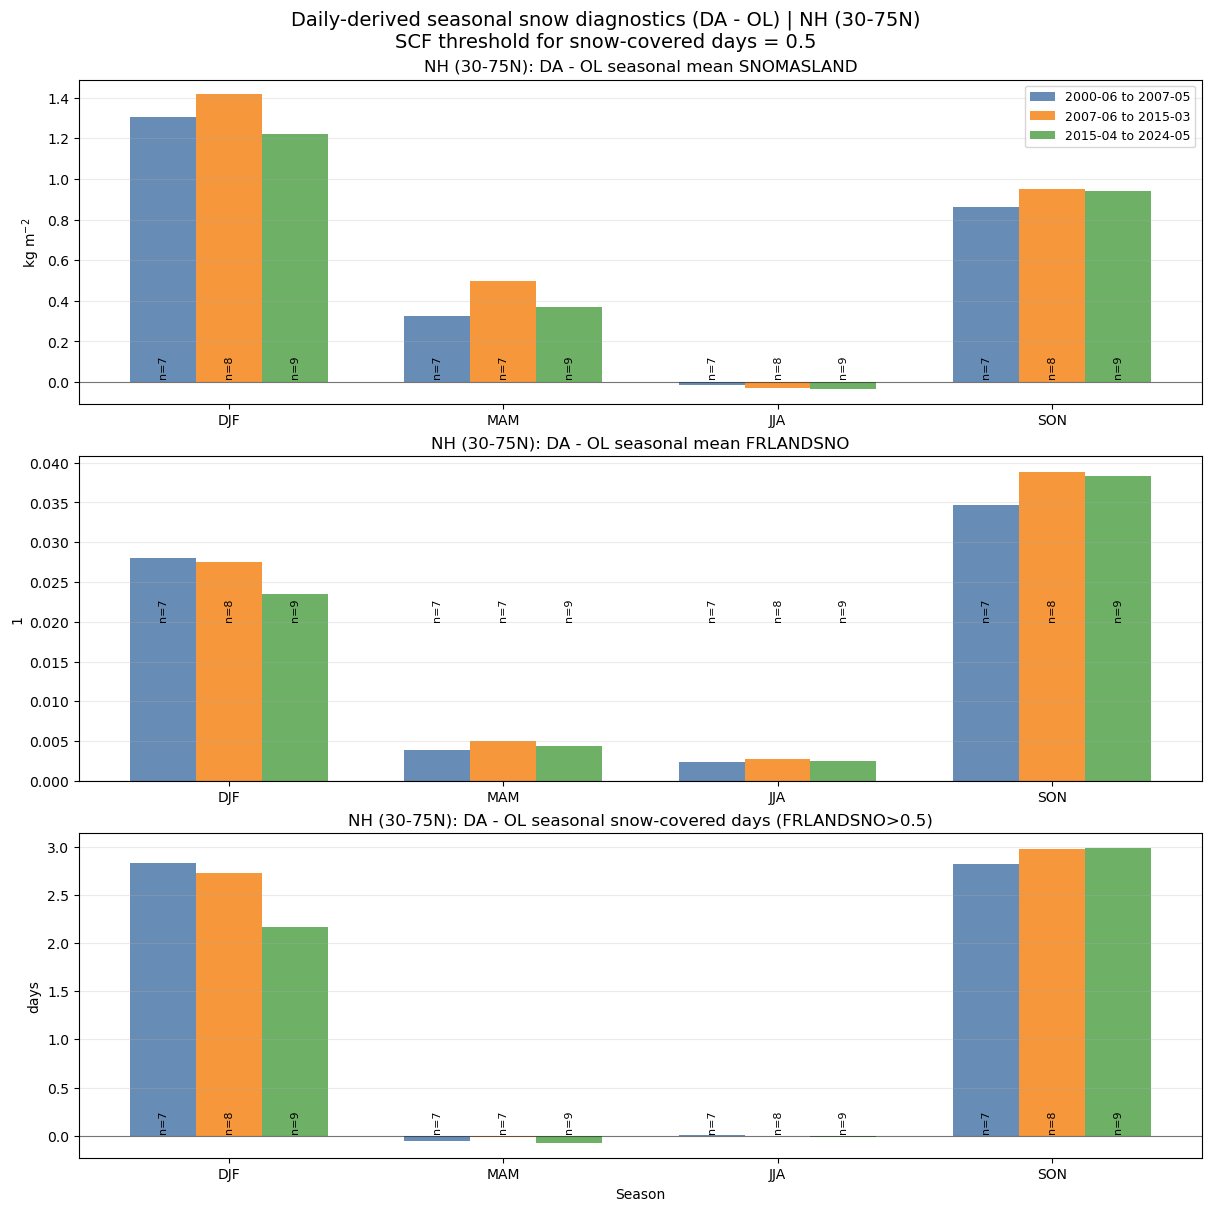

In [7]:
# -------------------------
# Regional DA-OL seasonal bar charts (focus region)
# -------------------------
if FOCUS_REGION not in set(period_region_summary_df["region"]):
    raise KeyError(f"FOCUS_REGION not found in region summaries: {FOCUS_REGION}")

plot_df = period_region_summary_df[period_region_summary_df["region"] == FOCUS_REGION].copy()
season_names = [s for s in SEASON_ORDER if s in set(plot_df["season"])]
period_names = [w[0] for w in window_bounds]

metric_specs = [
    ("snomas_diff", "DA - OL seasonal mean SNOMASLAND", "kg m$^{-2}$"),
    ("scf_diff", "DA - OL seasonal mean FRLANDSNO", "1"),
    ("snowdays_diff", f"DA - OL seasonal snow-covered days (FRLANDSNO>{SCF_THRESHOLD})", "days"),
]

fig, axes = plt.subplots(len(metric_specs), 1, figsize=(12, 4.0 * len(metric_specs)), constrained_layout=True)
axes = np.atleast_1d(axes)

x = np.arange(len(season_names))
width = 0.24 if len(period_names) >= 3 else 0.35
offsets = np.linspace(-width, width, len(period_names)) if len(period_names) > 1 else np.array([0.0])
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2"]

for ax, (metric, ylab, units) in zip(axes, metric_specs):
    for i, pname in enumerate(period_names):
        sub = (
            plot_df[plot_df["period"] == pname]
            .set_index("season")
            .reindex(season_names)
            .reset_index()
        )
        y = sub[metric].to_numpy(dtype=float)
        nrec = sub["n_records_window_season"].to_numpy(dtype=int)
        xpos = x + offsets[i]
        bars = ax.bar(xpos, y, width=width, label=pname, color=colors[i % len(colors)], alpha=0.85)

        # Annotate n season-records used in the window (same for all metrics at regional summary level).
        for b, nn in zip(bars, nrec):
            if not np.isfinite(b.get_height()):
                continue
            ax.text(
                b.get_x() + b.get_width() / 2.0,
                0.02 if (ax.get_ylim()[0] <= 0 <= ax.get_ylim()[1]) else b.get_height(),
                f"n={nn}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
            )

    ax.axhline(0.0, color="k", lw=0.8, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(season_names)
    ax.set_ylabel(units)
    ax.set_title(f"{FOCUS_REGION}: {ylab}")
    ax.grid(axis="y", alpha=0.25)

axes[0].legend(loc="best", fontsize=9)
axes[-1].set_xlabel("Season")
fig.suptitle(
    f"Daily-derived seasonal snow diagnostics (DA - OL) | {FOCUS_REGION}\n"
    f"SCF threshold for snow-covered days = {SCF_THRESHOLD}",
    fontsize=14,
)
savefig_if_enabled(fig, f"regional_seasonal_da_minus_ol_bars_{''.join(ch if ch.isalnum() else '_' for ch in FOCUS_REGION)}.png", dpi=FIG_DPI, save=SAVE_FIGURES)
plt.show()


## Seasonal Maps of `DA-OL` by Period (Tile Scatter Maps)

These are period-season tile summaries (rows = periods, cols = seasons) plotted with `cartopy` + `pcolormesh` on a reconstructed tile grid. A scatter fallback is kept in helpers, but the default here is `cartopy`.


Built pcolormesh grid from tile centers: nlat=373 nlon=964 n_tile=112573
Wrote figure: outputs_daily_snow_seasonal_ol_da/maps_snomas_diff_period_by_season.png


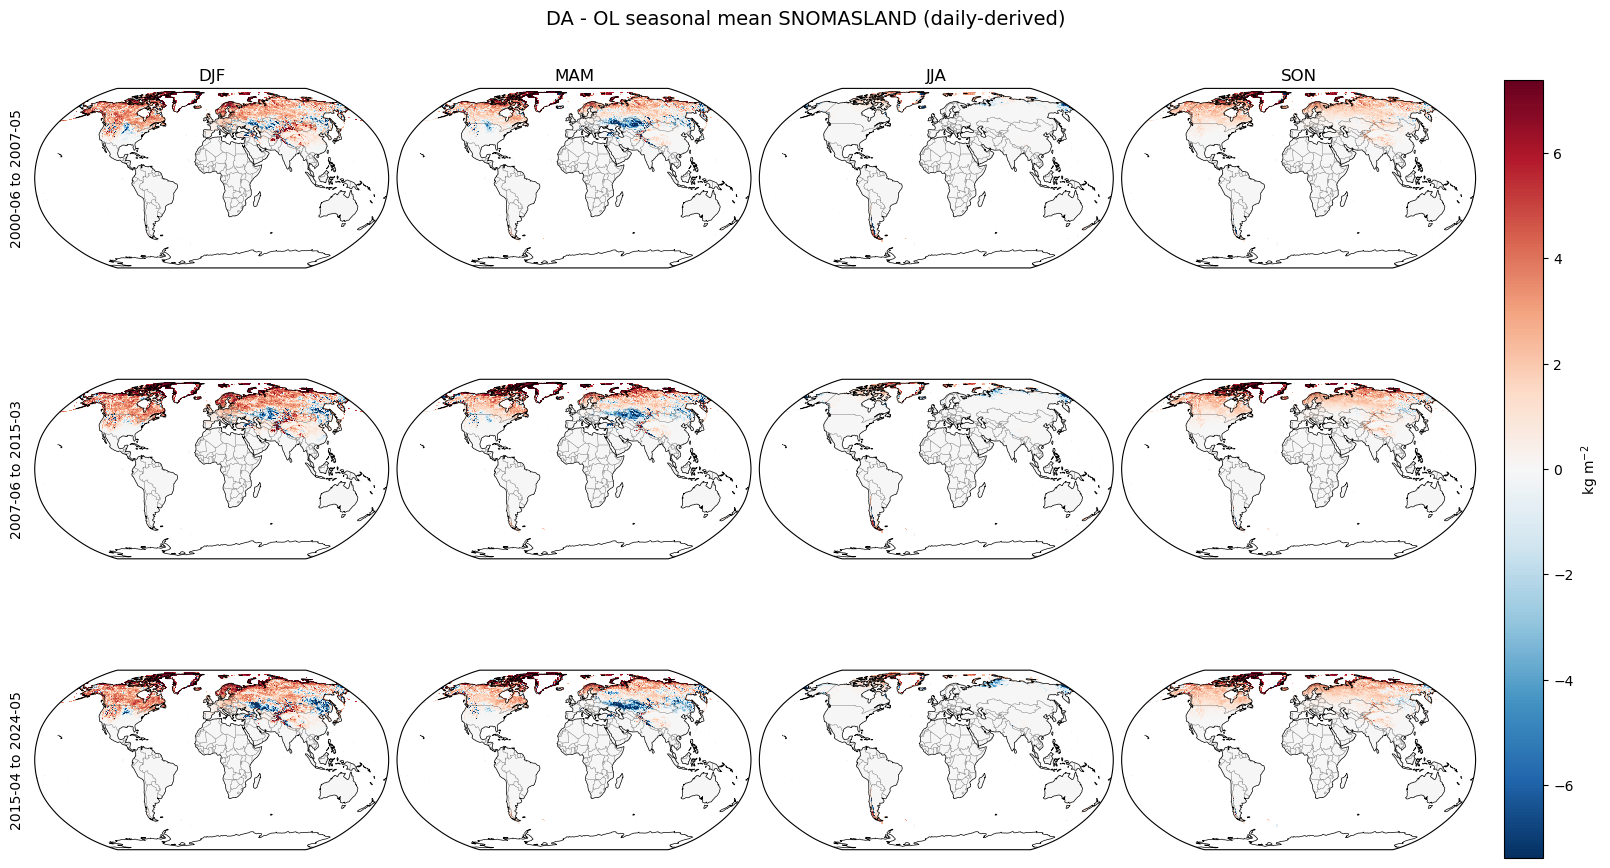

Wrote figure: outputs_daily_snow_seasonal_ol_da/maps_scf_diff_period_by_season.png


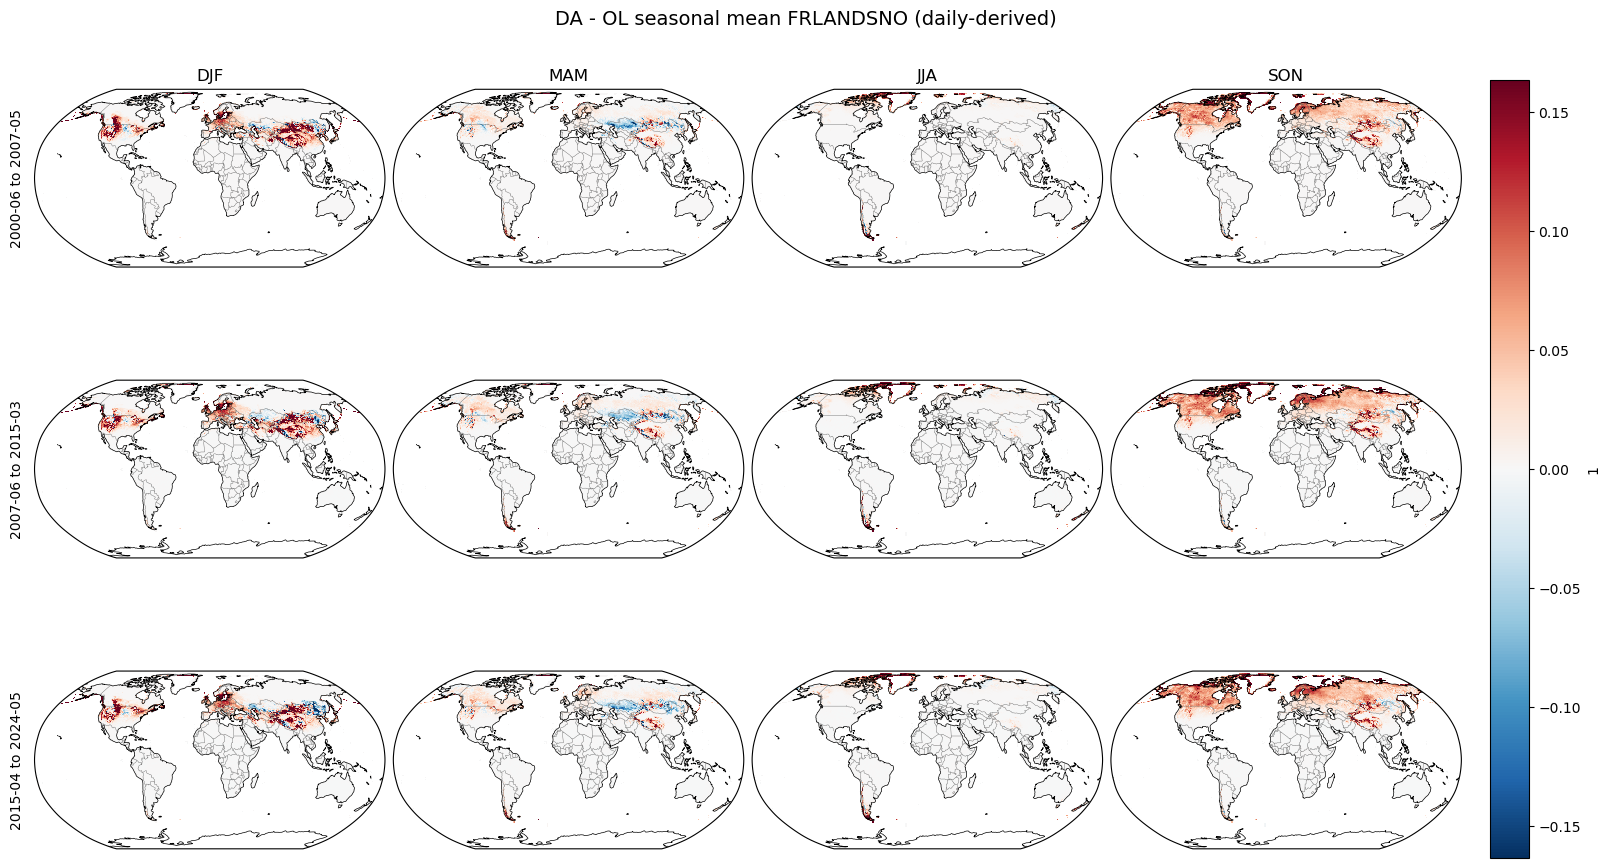

Wrote figure: outputs_daily_snow_seasonal_ol_da/maps_snowdays_diff_period_by_season.png


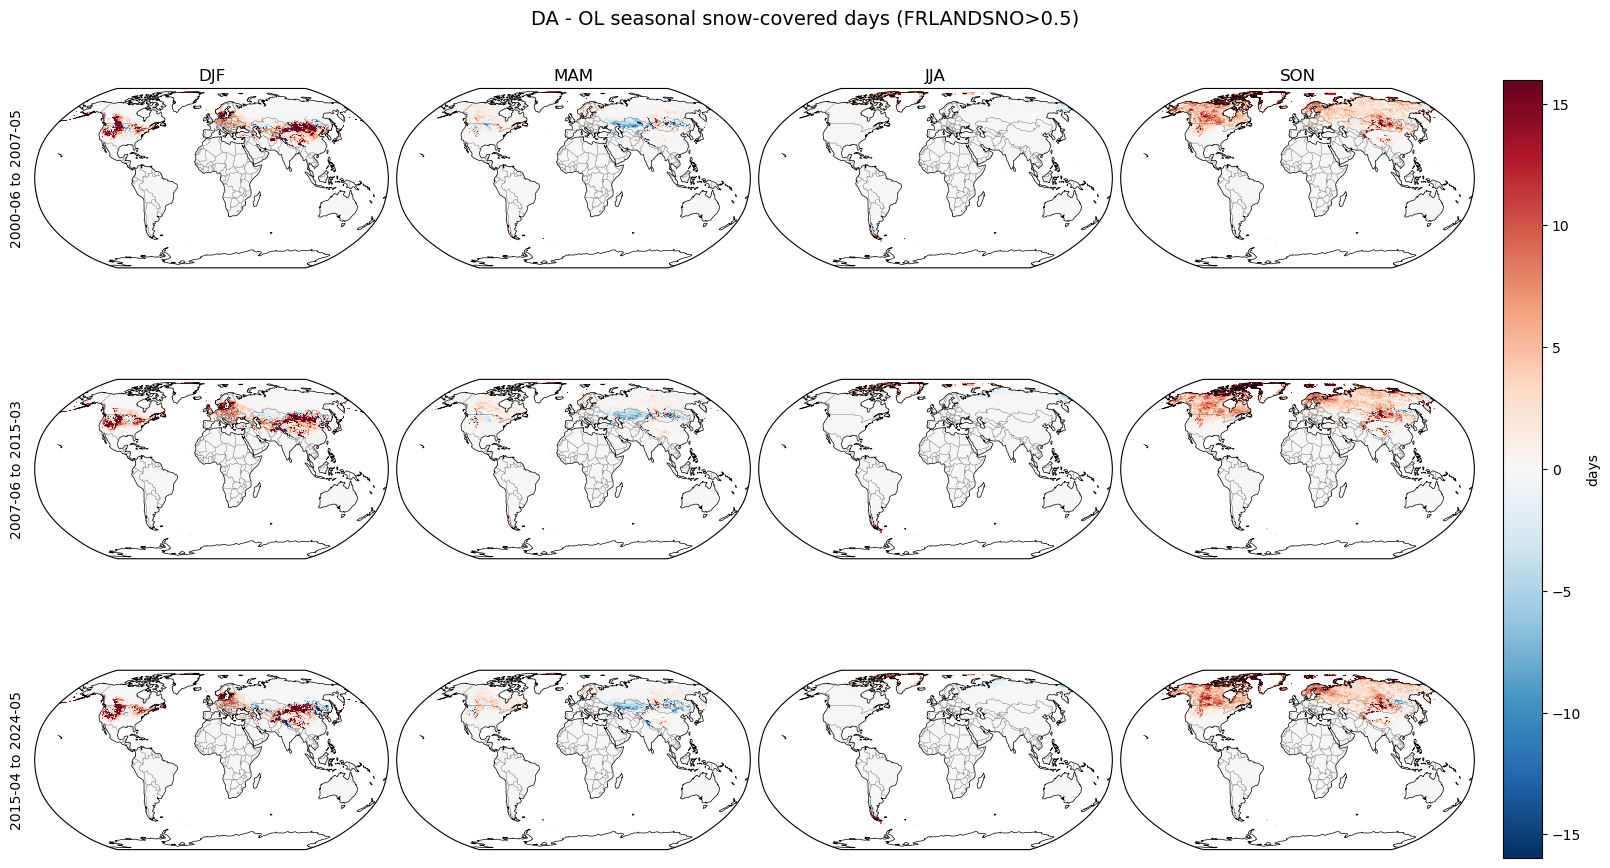

In [8]:
# -------------------------
# Period-season DA-OL maps for the three requested diagnostics (cartopy + pcolormesh)
# -------------------------
if not HAVE_CARTOPY:
    raise ImportError(
        "cartopy is not available in this environment. "
        f"Import error: {CARTOPY_IMPORT_ERROR}"
    )

# Build the tile->grid mapping once, then reuse for all map variables.
# If this fails (unexpected tile geometry), the scatter helper is still available as a fallback.
try:
    tile_grid_spec = build_tile_pcolormesh_grid(
        period_tile_summary_ds["lat"].values,
        period_tile_summary_ds["lon"].values,
        round_decimals=6,
    )
    print(
        "Built pcolormesh grid from tile centers:",
        f"nlat={tile_grid_spec['nlat']}",
        f"nlon={tile_grid_spec['nlon']}",
        f"n_tile={tile_grid_spec['n_tile']}",
    )
except Exception as exc:
    raise RuntimeError(
        "Failed to reconstruct a rectilinear grid for pcolormesh from tile lat/lon. "
        "If needed, use the scatter fallback helper instead. "
        f"Details: {exc}"
    )

map_specs = [
    ("snomas_diff", "DA - OL seasonal mean SNOMASLAND (daily-derived)", "kg m$^{-2}$", 99.0),
    ("scf_diff", "DA - OL seasonal mean FRLANDSNO (daily-derived)", "1", 99.0),
    ("snowdays_diff", f"DA - OL seasonal snow-covered days (FRLANDSNO>{SCF_THRESHOLD})", "days", 99.0),
]

for var_name, title, units, pct in map_specs:
    fig = plot_period_season_cartopy_pcolormesh_maps(
        period_tile_summary_ds,
        var_name=var_name,
        title=title,
        units=units,
        cmap="RdBu_r",
        pct=pct,
        tile_grid_spec=tile_grid_spec,
    )
    savefig_if_enabled(fig, f"maps_{var_name}_period_by_season.png", dpi=FIG_DPI, save=SAVE_FIGURES)
    plt.show()


## Optional: Seasonal-Year Regional Time Series (`OL`, `DA`, `DA-OL`)

This gives a time-evolution view for one region and one season at a time. It is useful for checking whether a period-average difference is driven by a few years or is persistent.


In [9]:
# -------------------------
# Build seasonal-year regional time series (for quick temporal diagnostics)
# -------------------------
if FOCUS_REGION not in REGION_DEFS:
    raise KeyError(f"FOCUS_REGION not in REGION_DEFS: {FOCUS_REGION}")

lat_vals = np.asarray(seasonal_ds["lat"].values, dtype=float)
lat0, lat1 = REGION_DEFS[FOCUS_REGION]
focus_tile_mask = (lat_vals >= lat0) & (lat_vals <= lat1)

record_meta_df = pd.DataFrame(
    {
        "record": seasonal_ds["record"].values.astype(int),
        "season": seasonal_ds["season"].values.astype(str),
        "season_year": seasonal_ds["season_year"].values.astype(int),
        "season_start": pd.to_datetime(seasonal_ds["season_start"].values),
        "season_end": pd.to_datetime(seasonal_ds["season_end"].values),
        "n_days_expected": seasonal_ds["n_days_expected"].values.astype(int),
        "complete_within_analysis_span": seasonal_ds["complete_within_analysis_span"].values.astype(int).astype(bool),
    }
)

exp_values = [str(x) for x in seasonal_ds["exp"].values]
exp_index = {k: i for i, k in enumerate(exp_values)}
iOL = exp_index["OL"]
iDA = exp_index["DA"]

arr_snomas = np.asarray(seasonal_ds["snomas_mean_daily"].values, dtype=np.float32)
arr_scf = np.asarray(seasonal_ds["frlandsno_mean_daily"].values, dtype=np.float32)
arr_snowdays = np.asarray(seasonal_ds["snowcovered_days"].values, dtype=np.float32)
valid_snomas_days = np.asarray(seasonal_ds["valid_snomas_days"].values, dtype=np.float32)
valid_scf_days = np.asarray(seasonal_ds["valid_scf_days"].values, dtype=np.float32)
n_days_expected = np.asarray(seasonal_ds["n_days_expected"].values, dtype=np.float32)

valid_frac_snomas = valid_snomas_days / n_days_expected[None, :, None]
valid_frac_scf = valid_scf_days / n_days_expected[None, :, None]

rows = []
for ir, rec in record_meta_df.iterrows():
    if not bool(rec["complete_within_analysis_span"]):
        continue

    # Common-valid masks across OL and DA at the tile level.
    common_snomas = (
        (valid_frac_snomas[iOL, ir, :] >= MIN_VALID_DAY_FRACTION_PER_SEASON)
        & (valid_frac_snomas[iDA, ir, :] >= MIN_VALID_DAY_FRACTION_PER_SEASON)
    )
    common_scf = (
        (valid_frac_scf[iOL, ir, :] >= MIN_VALID_DAY_FRACTION_PER_SEASON)
        & (valid_frac_scf[iDA, ir, :] >= MIN_VALID_DAY_FRACTION_PER_SEASON)
    )

    m_snomas = focus_tile_mask & common_snomas
    m_scf = focus_tile_mask & common_scf

    def regmean(vec, mask):
        return float(np.nanmean(vec[mask])) if np.any(mask) else np.nan

    sn_ol = regmean(arr_snomas[iOL, ir, :], m_snomas)
    sn_da = regmean(arr_snomas[iDA, ir, :], m_snomas)
    scf_ol = regmean(arr_scf[iOL, ir, :], m_scf)
    scf_da = regmean(arr_scf[iDA, ir, :], m_scf)
    sd_ol = regmean(arr_snowdays[iOL, ir, :], m_scf)
    sd_da = regmean(arr_snowdays[iDA, ir, :], m_scf)

    rows.append(
        {
            "record": int(rec["record"]),
            "season": str(rec["season"]),
            "season_year": int(rec["season_year"]),
            "season_start": rec["season_start"],
            "season_end": rec["season_end"],
            "region": FOCUS_REGION,
            "snomas_ol": sn_ol,
            "snomas_da": sn_da,
            "snomas_diff": (sn_da - sn_ol) if np.isfinite(sn_ol) and np.isfinite(sn_da) else np.nan,
            "scf_ol": scf_ol,
            "scf_da": scf_da,
            "scf_diff": (scf_da - scf_ol) if np.isfinite(scf_ol) and np.isfinite(scf_da) else np.nan,
            "snowdays_ol": sd_ol,
            "snowdays_da": sd_da,
            "snowdays_diff": (sd_da - sd_ol) if np.isfinite(sd_ol) and np.isfinite(sd_da) else np.nan,
            "n_tiles_snomas_common": int(np.sum(m_snomas)),
            "n_tiles_scf_common": int(np.sum(m_scf)),
        }
    )

seasonal_region_series_df = pd.DataFrame(rows).sort_values(["season_start", "season"]).reset_index(drop=True)
print(f"seasonal_region_series_df rows: {len(seasonal_region_series_df)}")
display(seasonal_region_series_df.head(16))


seasonal_region_series_df rows: 96


,record,season,season_year,season_start,season_end,region,snomas_ol,snomas_da,snomas_diff,scf_ol,scf_da,scf_diff,snowdays_ol,snowdays_da,snowdays_diff,n_tiles_snomas_common,n_tiles_scf_common
0,0,JJA,2000,2000-06-01,2000-08-31,NH (30-75N),6.377285,6.322036,-0.055249,0.026685,0.027514,0.000829,2.345425,2.315545,-0.029881,51137,51137
1,1,SON,2000,2000-09-01,2000-11-30,NH (30-75N),11.611098,12.099279,0.488181,0.245287,0.269214,0.023928,21.665310,23.861862,2.196552,51137,51137
2,2,DJF,2001,2000-12-01,2001-02-28,NH (30-75N),55.206841,56.095913,0.889072,0.624462,0.644390,0.019928,55.594189,57.426697,1.832508,51137,51137
3,3,MAM,2001,2001-03-01,2001-05-31,NH (30-75N),58.647854,58.666000,0.018147,0.393949,0.394380,0.000431,35.886852,35.663940,-0.222912,51137,51137
4,4,JJA,2001,2001-06-01,2001-08-31,NH (30-75N),4.979067,4.954851,-0.024216,0.021243,0.022324,0.001081,1.840350,1.844711,0.004361,51137,51137
5,5,SON,2001,2001-09-01,2001-11-30,NH (30-75N),11.231997,11.947639,0.715642,0.225522,0.251360,0.025838,19.913586,22.013905,2.100319,51137,51137
6,6,DJF,2002,2001-12-01,2002-02-28,NH (30-75N),55.900745,57.186195,1.285450,0.601599,0.627754,0.026156,53.475506,56.117764,2.642258,51137,51137
7,7,MAM,2002,2002-03-01,2002-05-31,NH (30-75N),62.363239,62.749477,0.386238,0.387920,0.389692,0.001772,35.350723,35.201439,-0.149284,51137,51137
8,8,JJA,2002,2002-06-01,2002-08-31,NH (30-75N),4.909636,4.918862,0.009226,0.022210,0.024720,0.002511,1.946907,1.966404,0.019497,51137,51137
9,9,SON,2002,2002-09-01,2002-11-30,NH (30-75N),10.922005,11.832726,0.910722,0.248947,0.287010,0.038062,22.023350,25.066135,3.042786,51137,51137


Wrote figure: outputs_daily_snow_seasonal_ol_da/seasonal_region_timeseries_da_minus_ol_NH__30_75N_.png


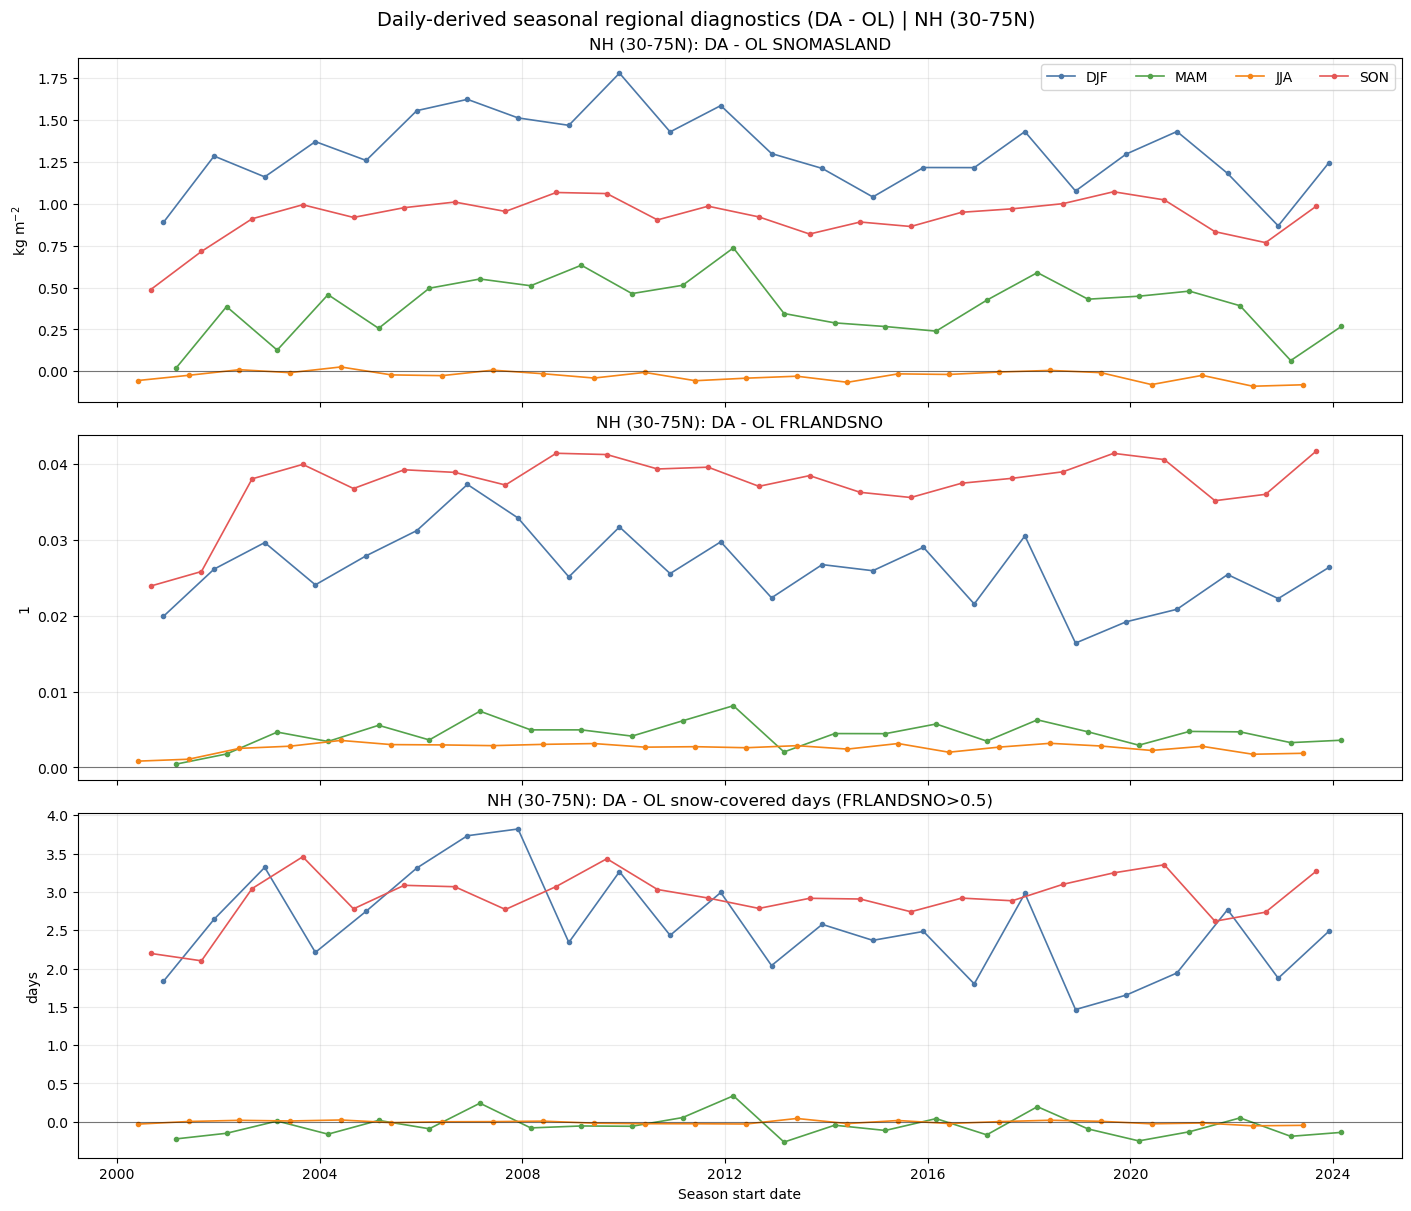

In [10]:
# -------------------------
# Plot seasonal-year DA-OL regional time series for the focus region
# -------------------------
if len(seasonal_region_series_df) == 0:
    raise RuntimeError("seasonal_region_series_df is empty")

metric_specs = [
    ("snomas_diff", "DA - OL SNOMASLAND", "kg m$^{-2}$"),
    ("scf_diff", "DA - OL FRLANDSNO", "1"),
    ("snowdays_diff", f"DA - OL snow-covered days (FRLANDSNO>{SCF_THRESHOLD})", "days"),
]
season_colors = {"DJF": "#4C78A8", "MAM": "#54A24B", "JJA": "#F58518", "SON": "#E45756"}

fig, axes = plt.subplots(len(metric_specs), 1, figsize=(14, 4.0 * len(metric_specs)), sharex=True, constrained_layout=True)
axes = np.atleast_1d(axes)

for ax, (metric, title, units) in zip(axes, metric_specs):
    for season in [s for s in SEASON_ORDER if s in set(seasonal_region_series_df["season"])]:
        sub = seasonal_region_series_df[seasonal_region_series_df["season"] == season].sort_values("season_start")
        if len(sub) == 0:
            continue
        ax.plot(pd.to_datetime(sub["season_start"]), sub[metric], marker="o", ms=3, lw=1.2, label=season, color=season_colors.get(season, None))

    ax.axhline(0.0, color="k", lw=0.8, alpha=0.5)
    ax.set_title(f"{FOCUS_REGION}: {title}")
    ax.set_ylabel(units)
    ax.grid(alpha=0.25)

axes[0].legend(loc="best", ncol=4)
axes[-1].set_xlabel("Season start date")
fig.suptitle(f"Daily-derived seasonal regional diagnostics (DA - OL) | {FOCUS_REGION}", fontsize=14)
savefig_if_enabled(fig, f"seasonal_region_timeseries_da_minus_ol_{''.join(ch if ch.isalnum() else '_' for ch in FOCUS_REGION)}.png", dpi=FIG_DPI, save=SAVE_FIGURES)
plt.show()


## Export Outputs (Tables + Tile Summary NetCDF)

The seasonal cache avoids re-reading daily files. These additional outputs make period summaries and plots reusable without recomputing.


In [11]:
# -------------------------
# Save reusable outputs
# -------------------------
period_tile_summary_ds.to_netcdf(PERIOD_TILE_SUMMARY_NC)
period_region_summary_df.to_csv(PERIOD_REGION_SUMMARY_CSV, index=False)
seasonal_region_series_df.to_csv(SEASONAL_REGION_SERIES_CSV, index=False)

print(f"Wrote NetCDF: {PERIOD_TILE_SUMMARY_NC}")
print(f"Wrote CSV:    {PERIOD_REGION_SUMMARY_CSV}")
print(f"Wrote CSV:    {SEASONAL_REGION_SERIES_CSV}")


Wrote NetCDF: outputs_daily_snow_seasonal_ol_da/daily_snow_period_tile_summary_SMAP_EASEv2_M36_GLOBAL_20000601_20240531.nc
Wrote CSV:    outputs_daily_snow_seasonal_ol_da/daily_snow_period_region_summary_SMAP_EASEv2_M36_GLOBAL_20000601_20240531.csv
Wrote CSV:    outputs_daily_snow_seasonal_ol_da/daily_snow_seasonal_region_series_SMAP_EASEv2_M36_GLOBAL_20000601_20240531.csv


## Notes / Assumptions

- `FRLANDSNO` is treated as **snow cover fraction** (`snowcover`) and averaged from daily values.
- `snowcovered_days` is a **count** of days in each season with `FRLANDSNO > 0.5`.
- `DJF` is labeled by the Jan/Feb year (e.g., Dec 2014 belongs to `DJF 2015`).
- Period-season means use the **common valid season-records** across OL and DA for each metric and tile.
- Region means are simple **unweighted tile means**. Add tile-area weighting later if needed.
- The first and last seasons in the analysis span may be partial; they are marked and excluded from period summaries.


## Full-Period Seasonal Snow-Day Change Maps (2x2)

This cell computes **seasonal mean snow-covered days** from all complete season-records over the full analysis period,
then maps `DA - OL` in a `2x2` panel (`DJF`, `MAM`, `JJA`, `SON`).

Snow-covered day definition: `FRLANDSNO > 0.5`.


Wrote figure: outputs_daily_snow_seasonal_ol_da/maps_snowdays_diff_full_period_by_season_2x2.png


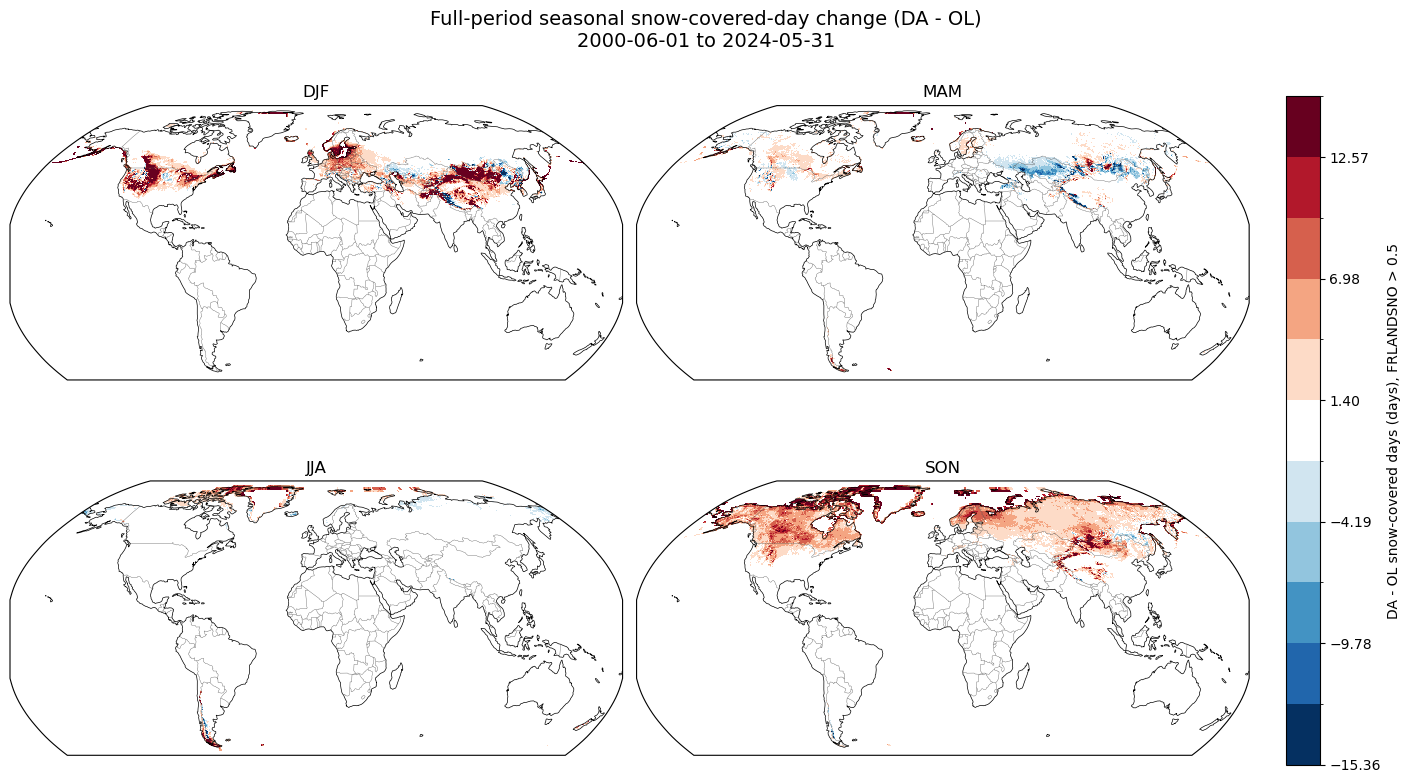

Wrote figure: outputs_daily_snow_seasonal_ol_da/maps_snomas_diff_full_period_by_season_2x2.png


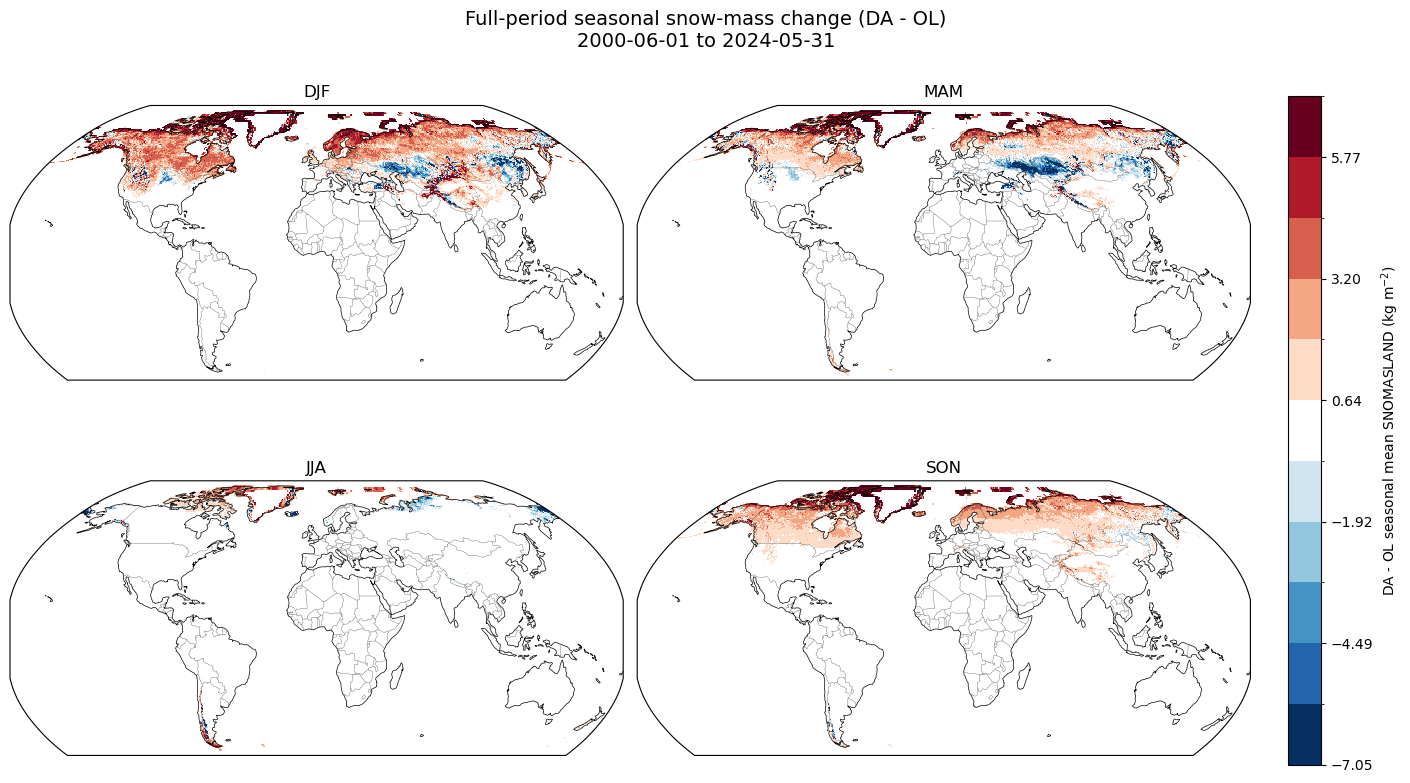

Wrote figure: outputs_daily_snow_seasonal_ol_da/maps_scf_diff_full_period_by_season_2x2.png


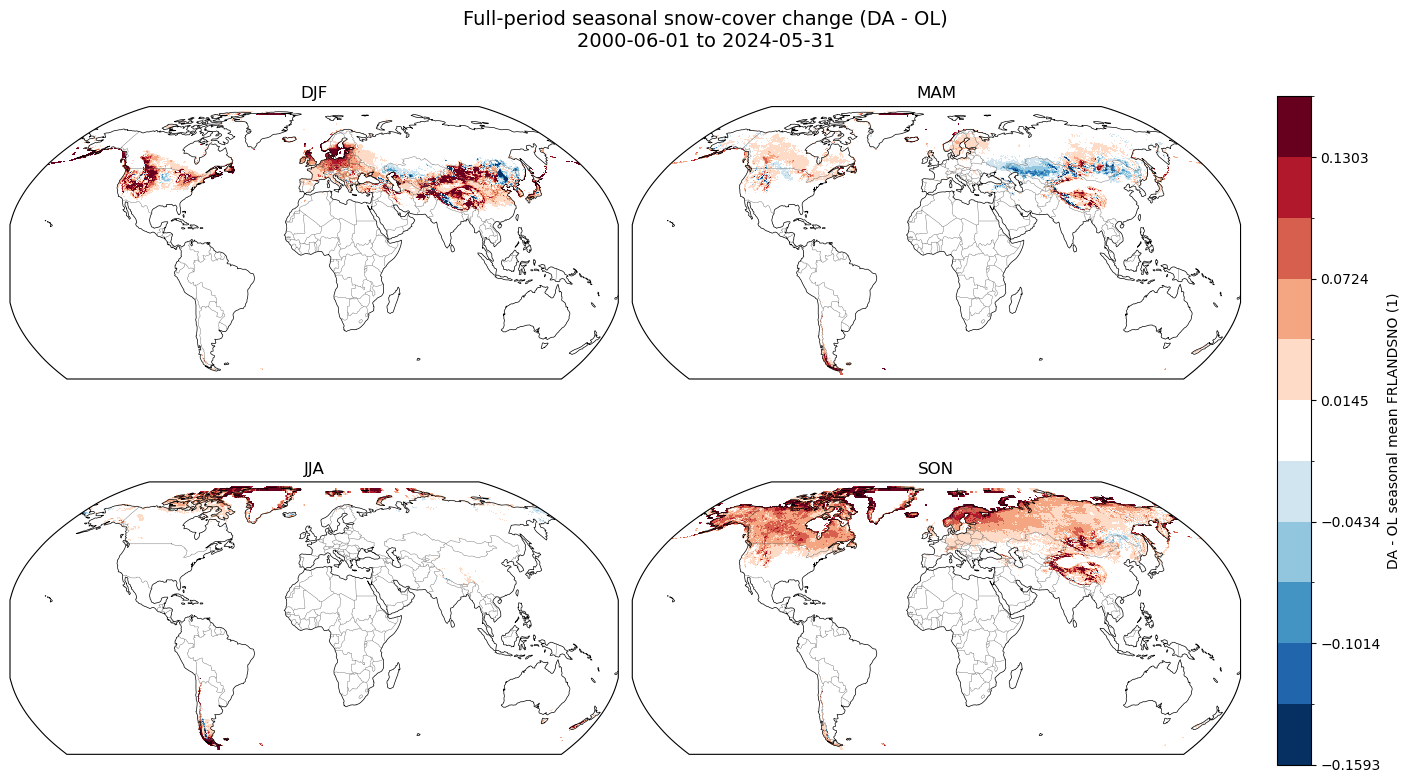

In [12]:
# -------------------------
# Full-period seasonal DA-OL change maps (2x2)
#   - snow mass (SNOMASLAND)
#   - snow cover fraction (FRLANDSNO)
#   - snow-covered days (FRLANDSNO threshold)
# -------------------------
if not HAVE_CARTOPY:
    raise ImportError(
        "cartopy is required for this plot. "
        f"Import error: {CARTOPY_IMPORT_ERROR}"
    )

# Rebuild compact record metadata from seasonal cache.
record_meta_df = pd.DataFrame(
    {
        "record": seasonal_ds["record"].values.astype(int),
        "season": seasonal_ds["season"].values.astype(str),
        "season_year": seasonal_ds["season_year"].values.astype(int),
        "season_start": pd.to_datetime(seasonal_ds["season_start"].values),
        "season_end": pd.to_datetime(seasonal_ds["season_end"].values),
        "n_days_expected": seasonal_ds["n_days_expected"].values.astype(int),
        "complete_within_analysis_span": seasonal_ds["complete_within_analysis_span"].values.astype(int).astype(bool),
    }
)

exp_values = [str(x) for x in seasonal_ds["exp"].values]
exp_index = {k: i for i, k in enumerate(exp_values)}
if not all(k in exp_index for k in ["OL", "DA"]):
    raise RuntimeError(f"Expected OL and DA in seasonal_ds exp dimension; found {exp_values}")

iOL = exp_index["OL"]
iDA = exp_index["DA"]

arr_snomas = np.asarray(seasonal_ds["snomas_mean_daily"].values, dtype=np.float32)      # [exp, record, tile]
arr_scf = np.asarray(seasonal_ds["frlandsno_mean_daily"].values, dtype=np.float32)       # [exp, record, tile]
arr_snowdays = np.asarray(seasonal_ds["snowcovered_days"].values, dtype=np.float32)       # [exp, record, tile]
valid_snomas_days = np.asarray(seasonal_ds["valid_snomas_days"].values, dtype=np.float32) # [exp, record, tile]
valid_scf_days = np.asarray(seasonal_ds["valid_scf_days"].values, dtype=np.float32)       # [exp, record, tile]
n_days_expected = np.asarray(seasonal_ds["n_days_expected"].values, dtype=np.float32)     # [record]

valid_frac_snomas = valid_snomas_days / n_days_expected[None, :, None]
valid_frac_scf = valid_scf_days / n_days_expected[None, :, None]
record_complete = record_meta_df["complete_within_analysis_span"].to_numpy(dtype=bool)

# Helper: nan-safe mean across record dimension without warning spam for all-NaN columns.
def mean_over_records_2d(x_rec_tile):
    num = np.nansum(x_rec_tile, axis=0)
    den = np.sum(np.isfinite(x_rec_tile), axis=0)
    out = np.full(x_rec_tile.shape[1], np.nan, dtype=np.float32)
    np.divide(num, den, out=out, where=den > 0)
    return out

season_names = [s for s in SEASON_ORDER if s in set(record_meta_df["season"])]
if len(season_names) == 0:
    raise RuntimeError("No seasonal records found in seasonal_ds")

n_tile = int(seasonal_ds.sizes["tile"])
full_season_snomas_diff = {}
full_season_scf_diff = {}
full_season_snowdays_diff = {}

for season in season_names:
    rec_mask = record_complete & (record_meta_df["season"].to_numpy(dtype=str) == season)

    if not np.any(rec_mask):
        full_season_snomas_diff[season] = np.full((n_tile,), np.nan, dtype=np.float32)
        full_season_scf_diff[season] = np.full((n_tile,), np.nan, dtype=np.float32)
        full_season_snowdays_diff[season] = np.full((n_tile,), np.nan, dtype=np.float32)
        continue

    rec_mask_2d = rec_mask[:, None]

    # SNOMASLAND: use common valid season-records across OL and DA for fairness.
    common_snomas = (
        rec_mask_2d
        & (valid_frac_snomas[iOL, :, :] >= MIN_VALID_DAY_FRACTION_PER_SEASON)
        & (valid_frac_snomas[iDA, :, :] >= MIN_VALID_DAY_FRACTION_PER_SEASON)
    )
    ol_snomas = np.where(common_snomas, arr_snomas[iOL, :, :], np.nan)
    da_snomas = np.where(common_snomas, arr_snomas[iDA, :, :], np.nan)
    full_season_snomas_diff[season] = mean_over_records_2d(da_snomas) - mean_over_records_2d(ol_snomas)

    # FRLANDSNO mean and snow-covered days: use common SCF-valid records across OL and DA.
    common_scf = (
        rec_mask_2d
        & (valid_frac_scf[iOL, :, :] >= MIN_VALID_DAY_FRACTION_PER_SEASON)
        & (valid_frac_scf[iDA, :, :] >= MIN_VALID_DAY_FRACTION_PER_SEASON)
    )

    ol_scf = np.where(common_scf, arr_scf[iOL, :, :], np.nan)
    da_scf = np.where(common_scf, arr_scf[iDA, :, :], np.nan)
    full_season_scf_diff[season] = mean_over_records_2d(da_scf) - mean_over_records_2d(ol_scf)

    ol_snowdays = np.where(common_scf, arr_snowdays[iOL, :, :], np.nan)
    da_snowdays = np.where(common_scf, arr_snowdays[iDA, :, :], np.nan)
    full_season_snowdays_diff[season] = mean_over_records_2d(da_snowdays) - mean_over_records_2d(ol_snowdays)

# Exclude Antarctica (tile centers south of -60 deg) from all full-period maps.
tile_lat = np.asarray(seasonal_ds["lat"].values, dtype=np.float32)
antarctica_mask = tile_lat < -60.0
for dct in (full_season_snomas_diff, full_season_scf_diff, full_season_snowdays_diff):
    for s in list(dct.keys()):
        v = np.asarray(dct[s], dtype=np.float32).copy()
        v[antarctica_mask] = np.nan
        dct[s] = v

# Build tile->grid mapping for pcolormesh once.
tile_grid_spec = build_tile_pcolormesh_grid(
    seasonal_ds["lat"].values,
    seasonal_ds["lon"].values,
    round_decimals=6,
)


def plot_full_period_2x2(diff_by_season, *, cbar_label, suptitle, out_name, pct=99.0):
    # Shared color scale across all available seasons.
    stack_for_limits = np.vstack([diff_by_season[s] for s in season_names])
    vmin, vmax = robust_symmetric_limits(stack_for_limits, pct=pct)
    if not (np.isfinite(vmin) and np.isfinite(vmax)):
        vmin, vmax = -1.0, 1.0
    if vmin == vmax:
        eps = 1e-6 if vmin == 0 else abs(vmin) * 1e-6
        vmin, vmax = vmin - eps, vmax + eps

    # Use discrete, symmetric diverging bins centered around zero.
    # Odd number of bins gives a true center bin; force that bin to white (0.0).
    from matplotlib.colors import BoundaryNorm, ListedColormap
    n_bins = 11
    levels = np.linspace(vmin, vmax, n_bins + 1, dtype=np.float32)
    base = plt.get_cmap("RdBu_r", n_bins)
    colors = base(np.arange(n_bins))
    colors[n_bins // 2] = np.array([1.0, 1.0, 1.0, 1.0])  # white center bin at zero
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(levels, ncolors=cmap.N, clip=False)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 8),
        subplot_kw={"projection": ccrs.Robinson()},
        constrained_layout=True,
    )
    axes = axes.ravel()
    pc = ccrs.PlateCarree()
    pcm = None

    for i, season in enumerate(["DJF", "MAM", "JJA", "SON"]):
        ax = axes[i]

        if season not in diff_by_season:
            ax.set_extent([-180, 180, -60, 90], crs=pc)
            ax.coastlines(linewidth=0.5)
            ax.set_title(f"{season} (not available)")
            continue

        z2d = tile_values_to_grid2d(diff_by_season[season], tile_grid_spec, dtype=np.float32)
        with np.errstate(invalid="ignore"):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                pcm = ax.pcolormesh(
                    tile_grid_spec["lon_edges_2d"],
                    tile_grid_spec["lat_edges_2d"],
                    z2d,
                    transform=pc,
                    cmap=cmap,
                    norm=norm,
                    shading="auto",
                    rasterized=True,
                )
                # Clip view to exclude Antarctica.
                ax.set_extent([-180, 180, -60, 90], crs=pc)
                ax.coastlines(linewidth=0.5)
                try:
                    ax.add_feature(cfeature.BORDERS, linewidth=0.25, edgecolor="0.3")
                except Exception:
                    pass
                ax.set_title(f"{season}")

    if pcm is not None:
        cbar = fig.colorbar(
            pcm,
            ax=axes.tolist(),
            shrink=0.9,
            pad=0.03,
            boundaries=levels,
            spacing="proportional",
        )
        cbar.set_ticks(levels[::2])
        cbar.set_label(cbar_label)

    fig.suptitle(
        f"{suptitle}\n"
        f"{pd.Timestamp(ANALYSIS_START).date()} to {pd.Timestamp(ANALYSIS_END).date()}",
        fontsize=14,
    )

    savefig_if_enabled(
        fig,
        out_name,
        dpi=FIG_DPI,
        save=SAVE_FIGURES,
    )
    plt.show()


# 1) Snow-covered days change (existing map, now with Antarctica excluded and simpler titles).
plot_full_period_2x2(
    full_season_snowdays_diff,
    cbar_label=f"DA - OL snow-covered days (days), FRLANDSNO > {SCF_THRESHOLD}",
    suptitle="Full-period seasonal snow-covered-day change (DA - OL)",
    out_name="maps_snowdays_diff_full_period_by_season_2x2.png",
)

# 2) Snow mass change.
plot_full_period_2x2(
    full_season_snomas_diff,
    cbar_label="DA - OL seasonal mean SNOMASLAND (kg m$^{-2}$)",
    suptitle="Full-period seasonal snow-mass change (DA - OL)",
    out_name="maps_snomas_diff_full_period_by_season_2x2.png",
)

# 3) Snow cover fraction change.
plot_full_period_2x2(
    full_season_scf_diff,
    cbar_label="DA - OL seasonal mean FRLANDSNO (1)",
    suptitle="Full-period seasonal snow-cover change (DA - OL)",
    out_name="maps_scf_diff_full_period_by_season_2x2.png",
)



